## Execução

In [633]:
from datetime import datetime
from zoneinfo import ZoneInfo

RUN_AT = datetime.now(ZoneInfo("America/Sao_Paulo"))
print(f"Última execução: {RUN_AT.strftime('%d/%m/%Y %H:%M:%S %Z')}")

Última execução: 21/07/2026 15:14:45 -03


## Imports

In [634]:
import warnings
warnings.filterwarnings("ignore")

In [635]:
import math
import os
import time
import requests
import pandas as pd
import json
import numpy as np
from pathlib import Path
from typing import Optional, Dict, List, Union
from unidecode import unidecode
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date, timedelta

import pandas_gbq
from google.auth import default
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

In [636]:
from funcoes_monitoramento import *
from funcoes_psi import *

In [637]:
from funcoes_monitoramento import compute_category_mix, _draw_rating_mix_panel

## Diretório

In [638]:
BASE_DIR = Path("data")
RAW_DIR = BASE_DIR / "raw"
TRUSTED_DIR = BASE_DIR / "trusted"
ANALYTICS_DIR = BASE_DIR / "analytics"

for path in [RAW_DIR, TRUSTED_DIR, ANALYTICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

## Base Blend4 em Produção

In [639]:
df_raw = pd.read_csv(ANALYTICS_DIR/"df_predict_blend4.csv")
df_raw = df_raw[df_raw["requested_at"] >= "2026-07-03"]

In [640]:
df_uniprop = df_raw[df_raw["qtd_proponentes"] == 1].copy()

df_multprop = df_raw[df_raw["qtd_proponentes"] >= 2].copy()

In [641]:
df = df_uniprop[(df_uniprop["REGRA_BLEND_4"] == "BLEND4")
# &(df_uniprop["income"] > 0) #Essa regra deverá ser excluída quando o modelo for implementado --> Contagem de 0/Nulo para variáveis (Score, Idade, Renda (inconsistência de valores))
## Voltar na base de Treino e ver se temos esses valores nulos/0
].copy()

In [642]:
df_bvs = df_uniprop[(df_uniprop["REGRA_BLEND_4"] == "E_BVS")
].copy()

In [643]:
df_uniprop = prepare_week_columns(df_uniprop, "requested_at")
df_multprop = prepare_week_columns(df_multprop, "requested_at")
df = prepare_week_columns(df, "requested_at")
df_bvs = prepare_week_columns(df_bvs, "requested_at")

## Gráficos

In [644]:
MODEL_ORDER = [
    "BLEND_4",
    "BLEND3_3",
    "BLEND_REGRESSAO_2026",
    "BVS_CUSTOM",
    "BVS_CUSTOM_V2",
    "HVA3",
    "HVA4",
    "HFT1"
]

MODEL_ORDER_GRAPH = [
    "BLEND_4",
    "BLEND3_3",
]

MODEL_COLOR_MAP = {
    "BLEND_4": "#3B82F6",             # blue
    "BLEND3_3": "#94A3B8",           # slate
    "BLEND_REGRESSAO_2026": "#8B5CF6",  # violet
    "BVS_CUSTOM": "#06B6D4",        # cyan
    "BVS_CUSTOM_V2": "#06d4ae",        # cyan
    "HVA3": "#14B8A6",               # teal
    "HVA4": "#6366F1",               # indigo
    "HFT1": "#F59E0B"
}

RATING_ORDER = ["A", "B", "C", "D", "E"]

RATING_COLOR_MAP = {
    "A": "#7DD3FC",
    "B": "#5EEAD4",
    "C": "#93C5FD",
    "D": "#818CF8",
    "E": "#334155",
}
RATING_TEXT_COLOR_MAP = {
    "A": "white",
    "B": "white",
    "C": "black",
    "D": "white",
    "E": "white",
}

In [645]:
PRE_ANALISE_ORDER = ["APROVAR", "DERIVAR", "REPROVAR"]

PRE_ANALISE_COLOR_MAP = {
    "APROVAR": "#9ECACA",
    "DERIVAR": "#B5BFE8",
    "REPROVAR": "#9AA5B1",
}

PRE_ANALISE_TEXT_COLOR_MAP = {
    "APROVAR": "white",
    "DERIVAR": "white",
    "REPROVAR": "white",
}

In [646]:
BINARY_METRICS = [
    "lead_elegivel_pre_analysis",
    "sent",
    "activated",
]

BINARY_ORDER = [0, 1]

BINARY_COLOR_MAP = {
    0: "#CBD5E1",  # muted gray
    1: "#86B8B8",  # muted teal (same family as APROVAR)
}

BINARY_TEXT_COLOR_MAP = {
    0: "white",
    1: "white",
}

BINARY_LABELS = {
    "lead_elegivel_pre_analysis": {0: "Não elegível", 1: "Elegível"},
    "sent": {0: "Não enviado", 1: "Enviado"},
    "activated": {0: "Não ativado", 1: "Ativado"},
}

METRIC_TITLES = {
    "lead_elegivel_pre_analysis": "Elegível",
    "sent": "Enviado",
    "activated": "Ativado",
}

# Uniproponente

# Primeira Semana
Acompanhamento diário do Mix de Modelos que vemos dos nossos leads.

In [647]:
WINDOW_DAYS = 8

df_daily = filter_monitoring_window(
    df,
    n_days=WINDOW_DAYS,
    mode="rolling",
)
print(f"Período: {df_daily['requested_at'].min()} → {df_daily['requested_at'].max()}")
print(f"Volume total: {len(df_daily):,}")

Período: 2026-07-13 00:00:00 → 2026-07-20 00:00:00
Volume total: 33,702


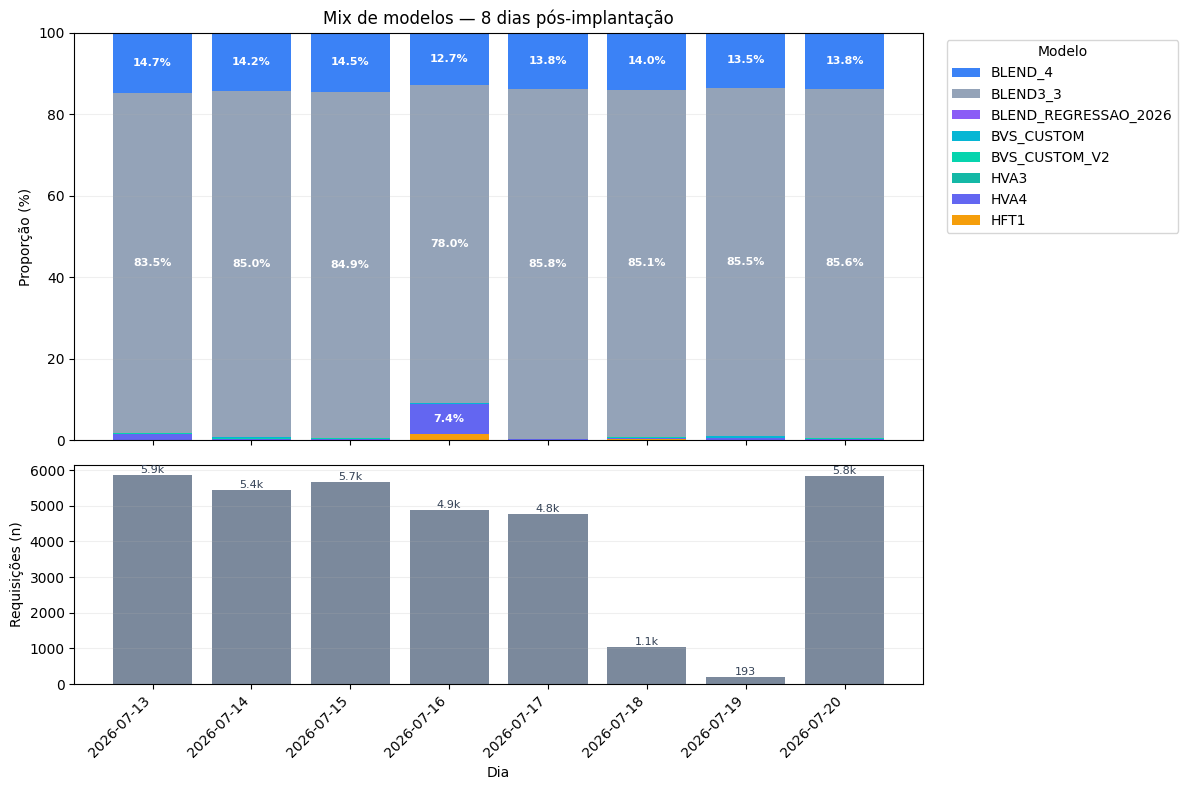

In [648]:
plot_daily_mix(
    df_daily,
    category_col="message_decisao",
    title=f"Mix de modelos — {WINDOW_DAYS} dias pós-implantação",
    category_order=MODEL_ORDER,
    color_map=MODEL_COLOR_MAP,
    reverse_stack=True,
    legend_title="Modelo",
    min_label_pct=3.0,
)

## Semanal

In [649]:
WINDOW_WEEKS = 6

df_weekly = filter_monitoring_week_window(
    df,
    n_weeks=WINDOW_WEEKS,
    mode="rolling",
)
print(f"Semanas: {df_weekly['year_week'].nunique()} | Volume: {len(df_weekly):,}")
print(f"Período: {df_weekly['requested_at'].min()} → {df_weekly['requested_at'].max()}")

Semanas: 4 | Volume: 65,528
Período: 2026-07-03 00:00:00 → 2026-07-20 00:00:00


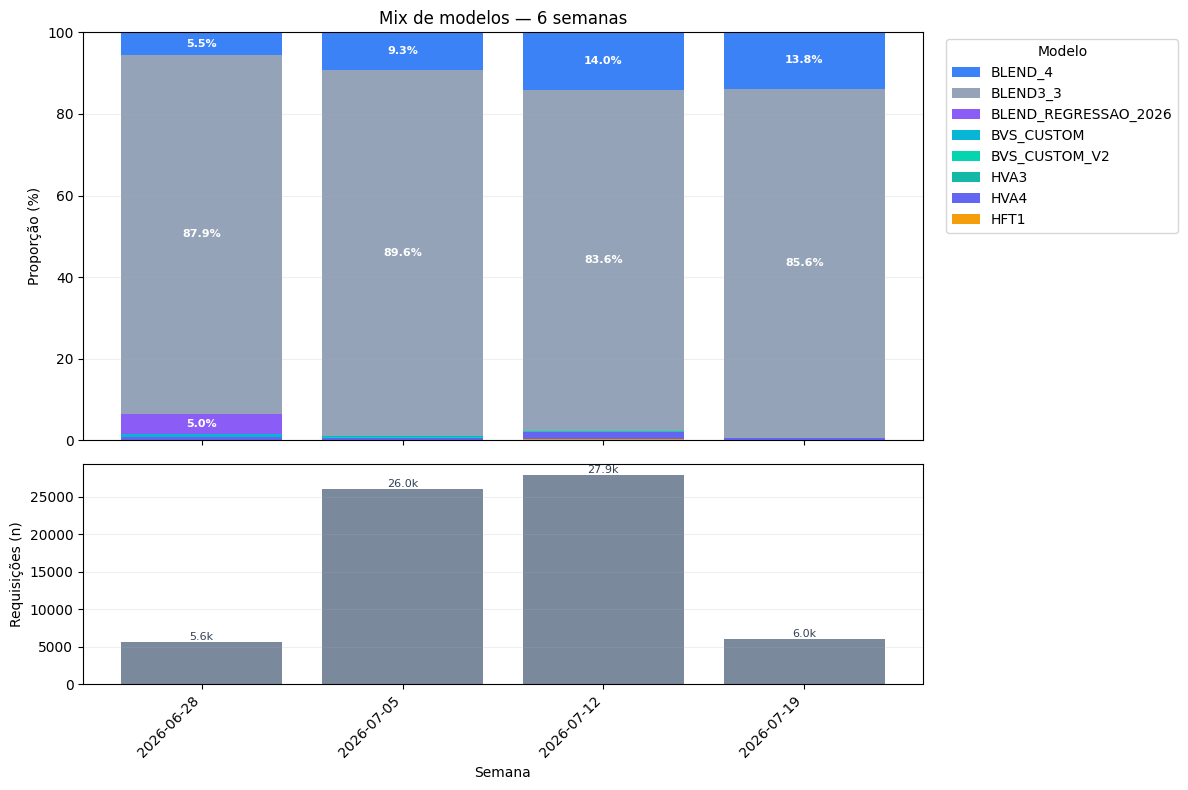

In [650]:
# Geral — modelos
plot_weekly_mix(
    df_weekly,
    category_col="message_decisao",
    title=f"Mix de modelos — {WINDOW_WEEKS} semanas",
    category_order=MODEL_ORDER,
    color_map=MODEL_COLOR_MAP,
    reverse_stack=True,
    legend_title="Modelo",
    min_label_pct=3.0,
)

## Mix de Rating BLEND4 vs. BLEND3

Esse Mix de Rating não é exatamente o Mix de Rating visto na tabela do Funil, pois estamos avaliando o público que tem score Blend4, ou seja excluindo o público E-BVS, negado diretamente.

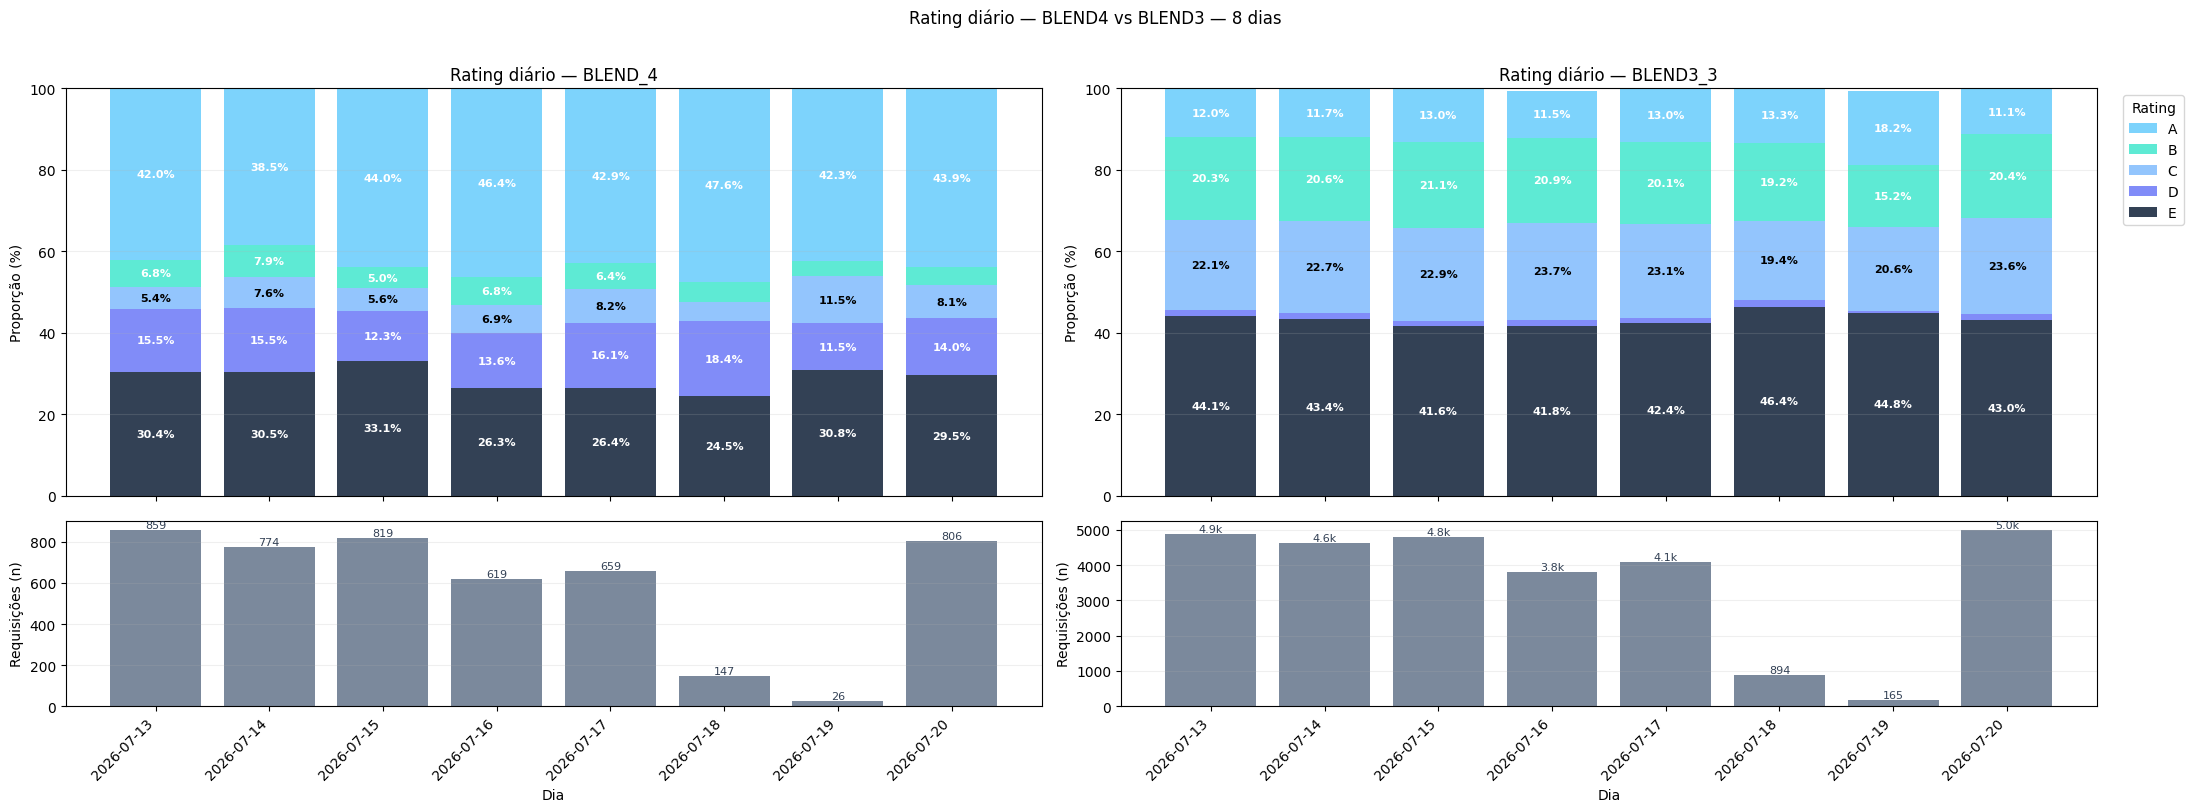

In [651]:
models_data = []
for model in MODEL_ORDER_GRAPH:
    df_model = df_daily[df_daily["message_decisao"] == model]
    if df_model.empty:
        continue

    pct_df, _, volume = compute_category_mix(
        df_model,
        category_col="message_classificacao",
        time_grain="day",
    )
    models_data.append((model, pct_df, volume))

if not models_data:
    print("[skip] Sem dados para rating diário comparável")
else:
    all_periods = sorted(set().union(*[pct.index for _, pct, _ in models_data]))
    aligned = [
        (
            model,
            pct_df.reindex(all_periods, fill_value=0),
            volume.reindex(all_periods, fill_value=0),
        )
        for model, pct_df, volume in models_data
    ]

    n = len(aligned)
    fig, axes = plt.subplots(
        2, n,
        figsize=(11 * n, 8),
        sharex="col",
        gridspec_kw={"height_ratios": [2.2, 1]},
    )
    if n == 1:
        axes = axes.reshape(2, 1)

    for col, (model, pct_df, volume) in enumerate(aligned):
        _draw_rating_mix_panel(
            axes[0, col],
            axes[1, col],
            pct_df,
            volume,
            panel_title=f"Rating diário — {model}",
            xlabel="Dia",
            category_order=RATING_ORDER,
            color_map=RATING_COLOR_MAP,
            text_color_map=RATING_TEXT_COLOR_MAP,
            reverse_stack=True,
            min_label_pct=5.0,
            show_legend=(col == n - 1),  # legenda só no painel da direita
            legend_title="Rating",
        )

    fig.suptitle(
        f"Rating diário — BLEND4 vs BLEND3 — {WINDOW_DAYS} dias",
        y=1.01,
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()

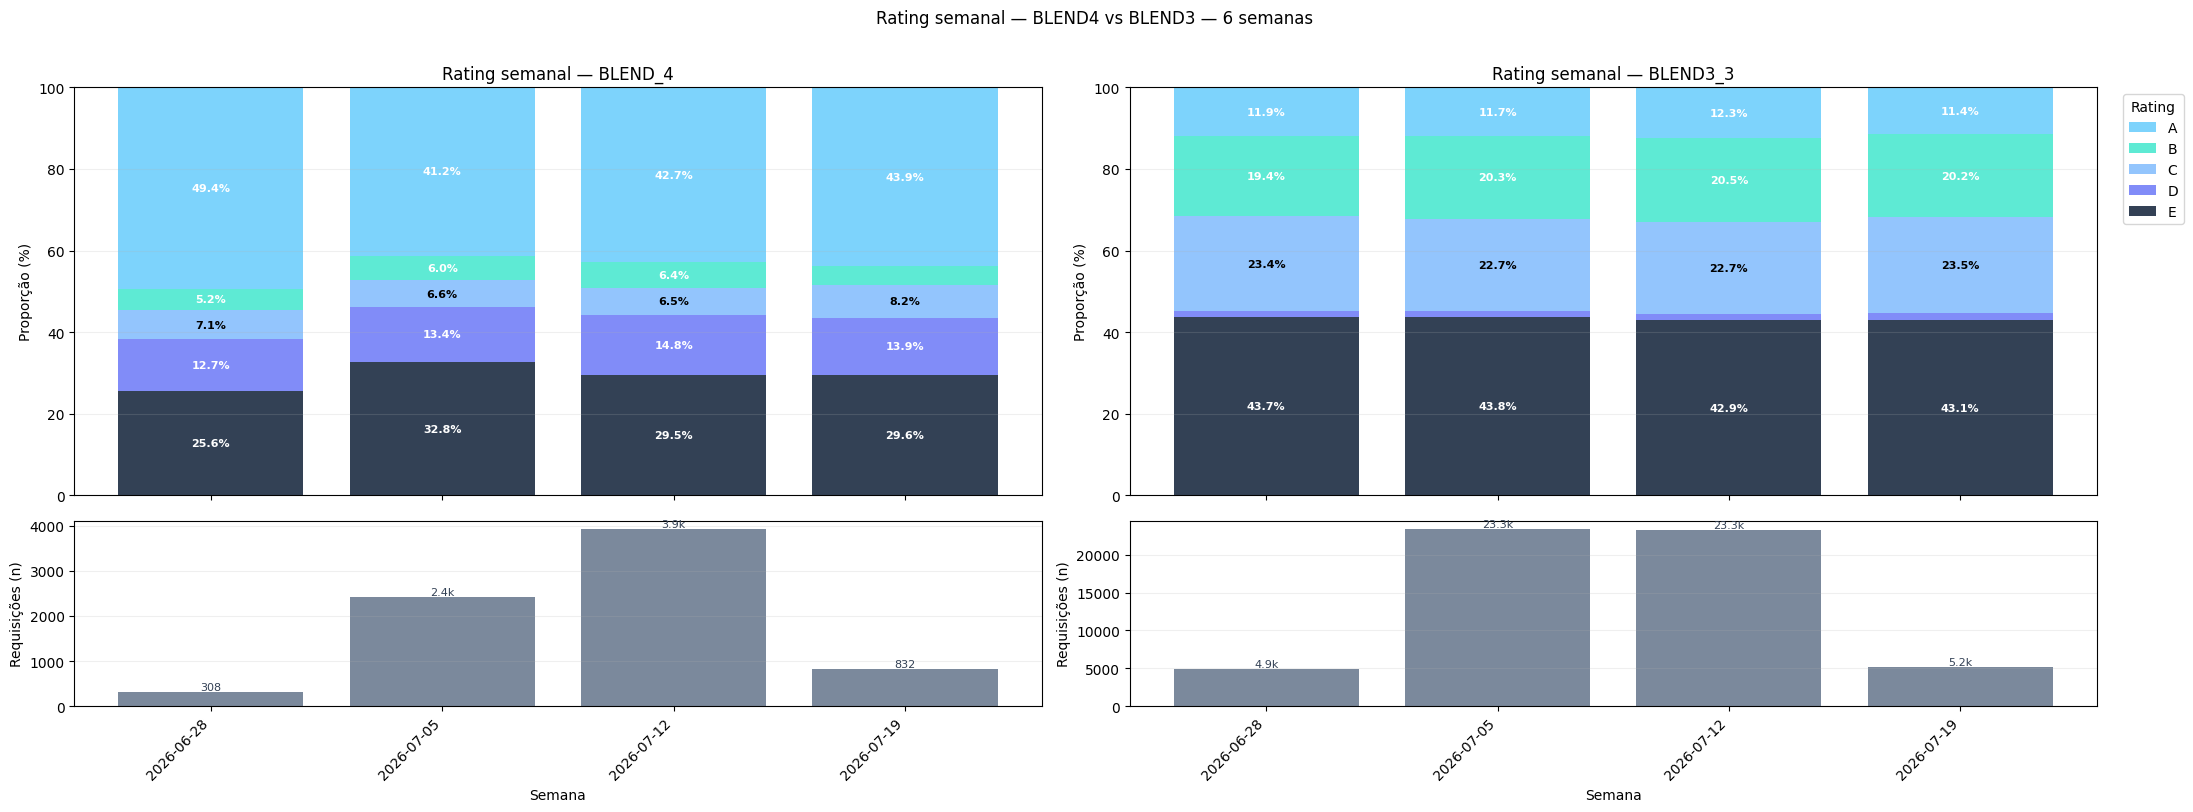

In [652]:
models_data = []
for model in MODEL_ORDER_GRAPH:
    df_model = df_weekly[df_weekly["message_decisao"] == model]
    if df_model.empty:
        continue

    pct_df, _, volume = compute_category_mix(
        df_model,
        category_col="message_classificacao",
        time_grain="week",
    )
    models_data.append((model, pct_df, volume))

if not models_data:
    print("[skip] Sem dados para rating semanal comparável")
else:
    all_periods = sorted(set().union(*[pct.index for _, pct, _ in models_data]))
    aligned = [
        (
            model,
            pct_df.reindex(all_periods, fill_value=0),
            volume.reindex(all_periods, fill_value=0),
        )
        for model, pct_df, volume in models_data
    ]

    n = len(aligned)
    fig, axes = plt.subplots(
        2, n,
        figsize=(11 * n, 8),
        sharex="col",
        gridspec_kw={"height_ratios": [2.2, 1]},
    )
    if n == 1:
        axes = axes.reshape(2, 1)

    for col, (model, pct_df, volume) in enumerate(aligned):
        _draw_rating_mix_panel(
            axes[0, col],
            axes[1, col],
            pct_df,
            volume,
            panel_title=f"Rating semanal — {model}",
            xlabel="Semana",
            category_order=RATING_ORDER,
            color_map=RATING_COLOR_MAP,
            text_color_map=RATING_TEXT_COLOR_MAP,
            reverse_stack=True,
            min_label_pct=5.0,
            show_legend=(col == n - 1),
            legend_title="Rating",
        )

    fig.suptitle(
        f"Rating semanal — BLEND4 vs BLEND3 — {WINDOW_WEEKS} semanas",
        y=1.01,
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()

# Comparação: Score CR vs. Score Manual
Nessa secção queremos entender se não há nenhum erro de escoragem no Modelo BLEND4, ou seja, se score que está na CR é o mesmo que o escorado manualmente.

## Scores Blend4

In [653]:
df_blend4 = df[df['message_decisao'].isin(['BLEND_4'])]

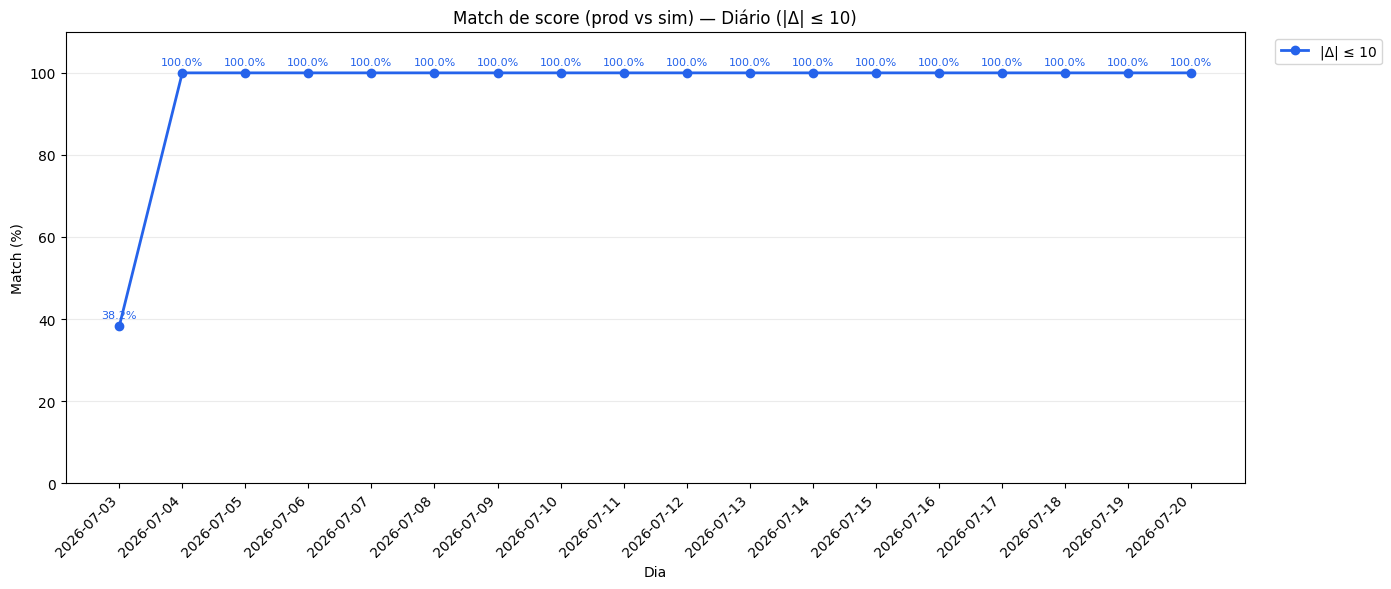

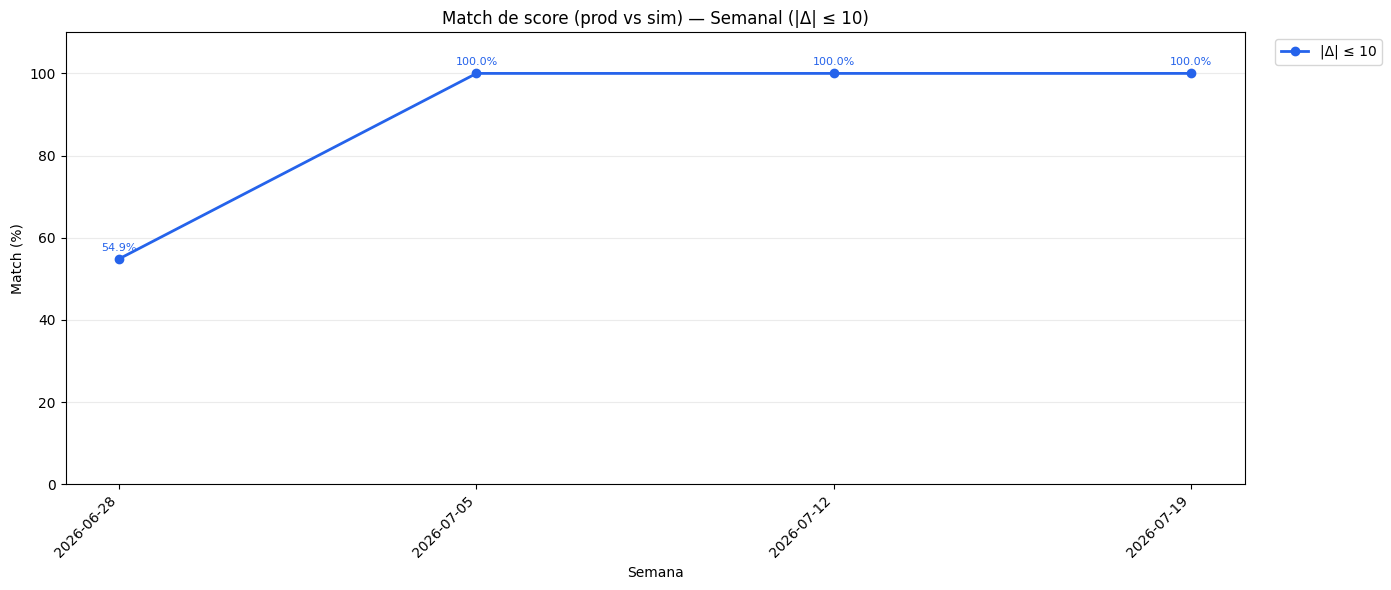

In [654]:
# Tabelas (como o score_summary que você já usa, mas por período)
daily_summary, weekly_summary = plot_score_match_monitoring(
    df_blend4,
    production_score_col="message_blendRegressaoPredict",
    simulated_score_col="pred_blend4_1_to_score",
    model_col=None,          # geral; use "message_decisao" para linha por modelo
    match_tolerance=10,      # coluna pct_match_abs_le_10
    show_volume=False,
)

In [655]:
daily_summary[["period", "volume_total", "pct_match_abs_le_10", "score_abs_diff_mean"]]

,period,volume_total,pct_match_abs_le_10,score_abs_diff_mean
0,2026-07-03,225.0,38.22,18.5
1,2026-07-04,83.0,100.00,0.0
2,2026-07-05,19.0,100.00,0.0
3,2026-07-06,569.0,100.00,0.0
4,2026-07-07,504.0,100.00,0.0
5,2026-07-08,454.0,100.00,0.0
6,2026-07-09,353.0,100.00,0.0
7,2026-07-10,395.0,100.00,0.0
8,2026-07-11,131.0,100.00,0.0
9,2026-07-12,36.0,100.00,0.0


## Ratings
No caos dos Ratings, o que queremos é entender se em dias que houve alguma falha de escoragem, se houve alteração no Mix.

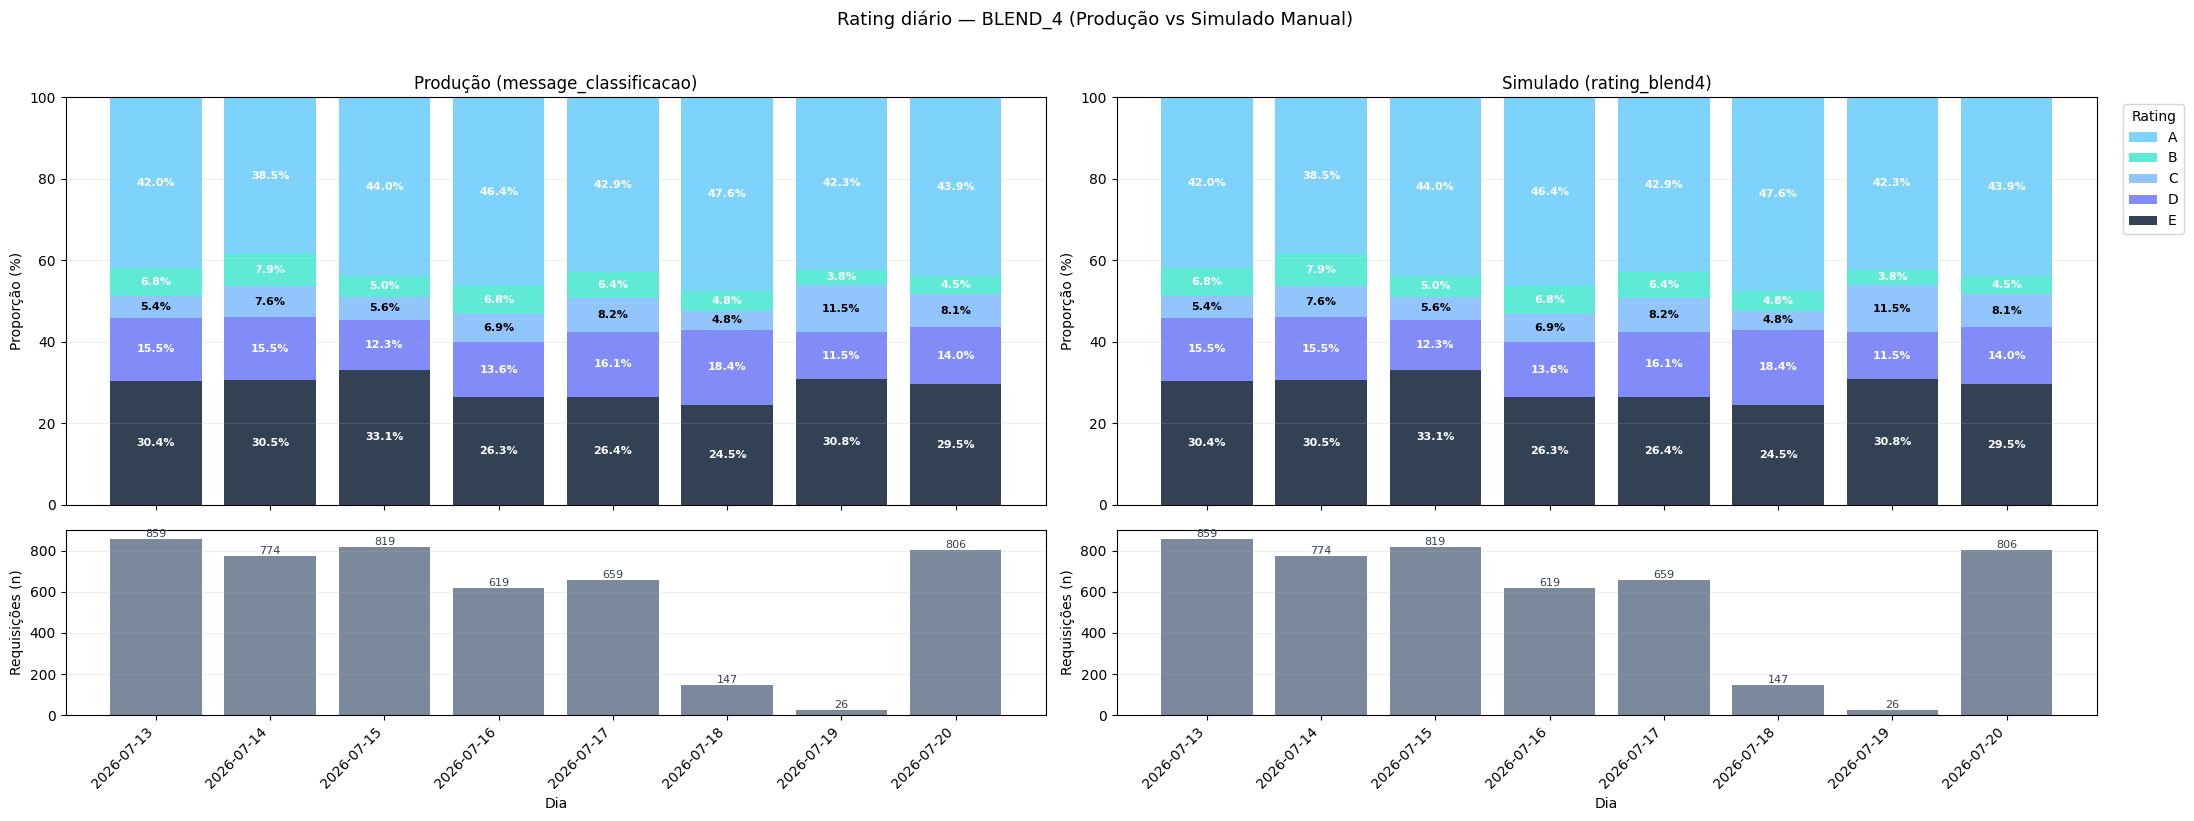

In [656]:
MODELS = ["BLEND_4"]

for model in MODELS:
    df_model = df_daily[df_daily["message_decisao"] == model]

    plot_daily_rating_comparison(
        df_model,
        title=f"Rating diário — {model} (Produção vs Simulado Manual)",
        production_rating_col = "message_classificacao",
        simulated_rating_col = "rating_manual_blend4",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        min_label_pct=3.0,
    )

In [657]:
for model in MODELS:
    pivot = pd.crosstab(
        df_daily.loc[df_daily["message_decisao"] == model, "message_classificacao"],
        df_daily.loc[df_daily["message_decisao"] == model, "rating_manual_blend4"],
        margins=True,
    )
    print(model)
    display(pivot)

BLEND_4


rating_manual_blend4,A,B,C,D,E,All
message_classificacao,,,,,,
A,2024,0,0,0,0,2024
B,0,288,0,0,0,288
C,0,0,323,0,0,323
D,0,0,0,687,0,687
E,0,0,0,0,1387,1387
All,2024,288,323,687,1387,4709


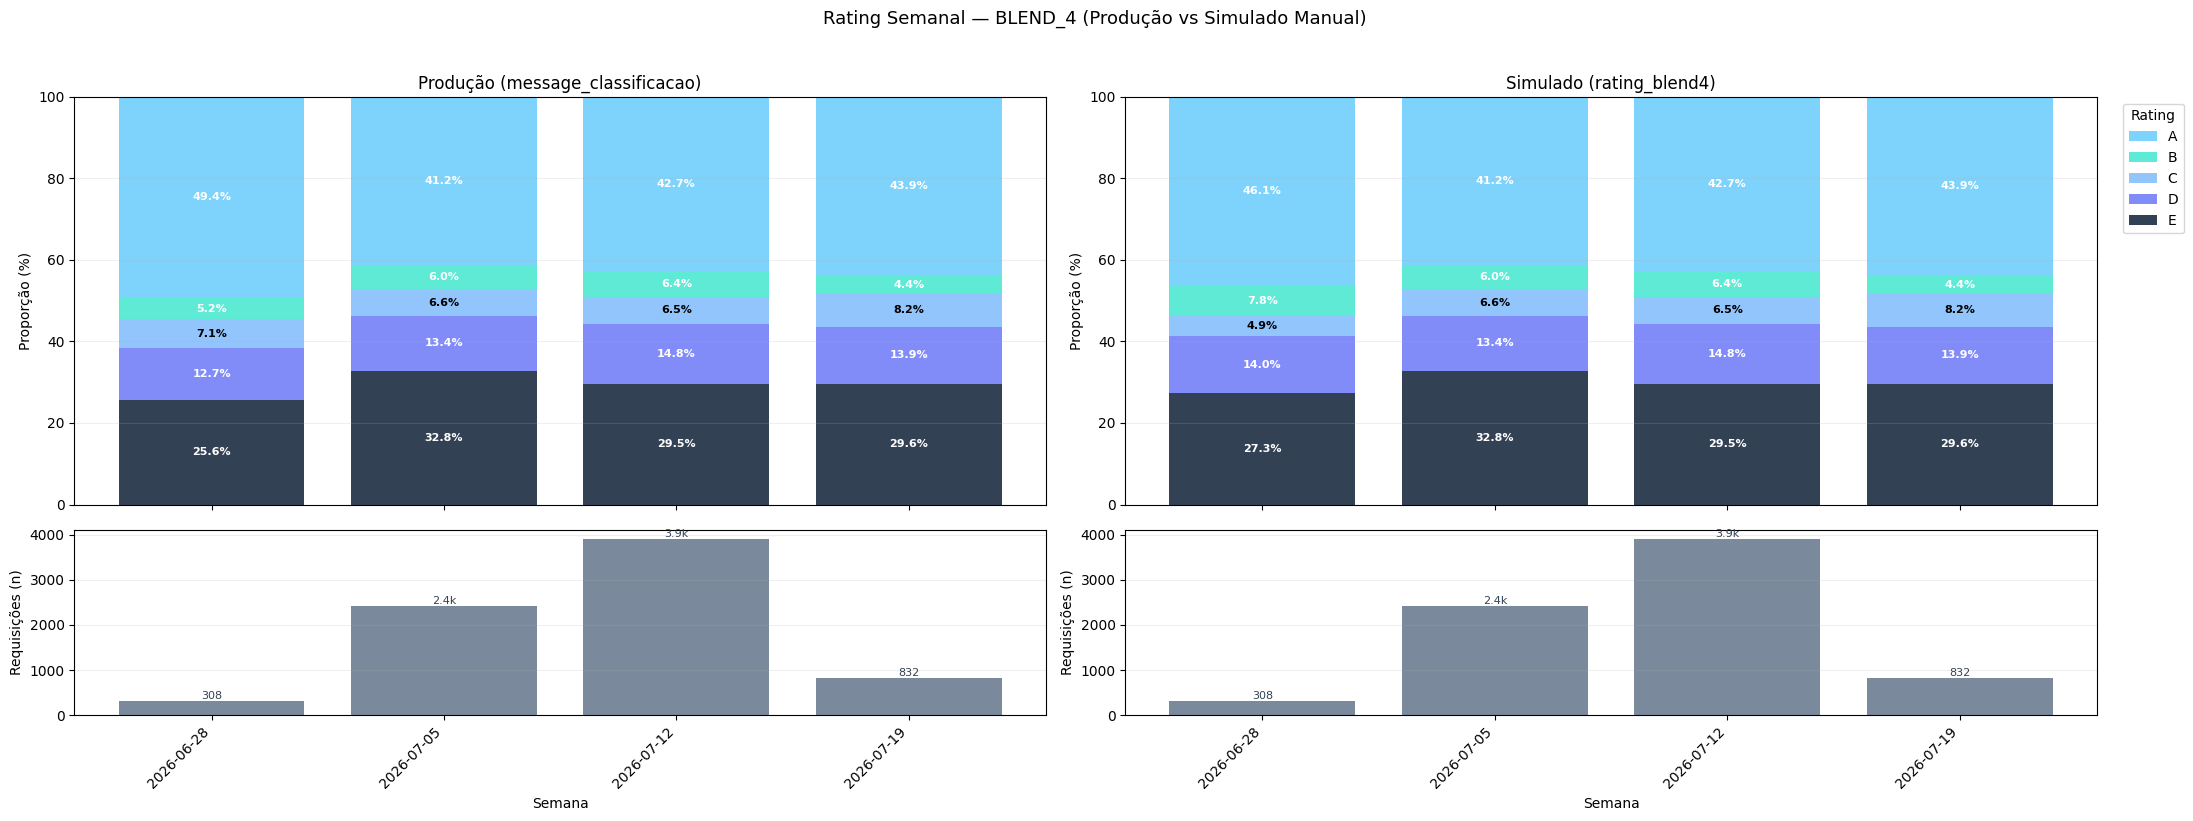

In [658]:
MODELS = ["BLEND_4"]

for model in MODELS:
    df_model = df_weekly[df_weekly["message_decisao"] == model]

    plot_weekly_rating_comparison(
        df_model,
        title=f"Rating Semanal — {model} (Produção vs Simulado Manual)",
        production_rating_col = "message_classificacao",
        simulated_rating_col = "rating_manual_blend4",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        min_label_pct=3.0,
    )

In [659]:
for model in MODELS:
    pivot = pd.crosstab(
        df_weekly.loc[df_weekly["message_decisao"] == model, "message_classificacao"],
        df_weekly.loc[df_weekly["message_decisao"] == model, "rating_manual_blend4"],
        margins=True,
    )
    print(model)
    display(pivot)

BLEND_4


rating_manual_blend4,A,B,C,D,E,All
message_classificacao,,,,,,
A,3178,11,0,0,0,3189
B,1,446,2,0,0,449
C,0,0,497,9,0,506
D,0,0,0,1053,6,1059
E,0,0,0,1,2274,2275
All,3179,457,499,1063,2280,7478


## PSI das Variáveis

In [660]:
model_vars = [
    "score_proposto__bvs",
    "SERASA_CHSV5",
    "age",
    "property_type",
    "qtde_restricoes__consulta_realizada",
    "income_commitment",
    "agency_pc4_mais_100_contratos__pc_categorias",
    "city_pc4_mais_100_contratos__pc_categorias",
    "flag_tem__contratos_anteriores",
    "flag_teve_boleto_atrasado__contratos_anteriores",
    "agency_pc4_mais_100_contratos__pc_categorias_is_null",
    "city_pc4_mais_100_contratos__pc_categorias_is_null",
    "pred_blend4_1_to_score",
]

In [661]:
# VARIABLE_LABELS = {
#     "score_proposto__bvs__normalized4_1": "Score BVS",
#     "SERASA_CHSV5__normalized4_1": "Score Serasa CHSV5",
#     "age__normalized4_1": "Idade",
#     "property_type": "Tipo de imóvel",
#     "qtde_restricoes__consulta_realizada__normalized4_1": "Qtd. restrições",
#     "income_commitment__normalized4_1": "Comprometimento de renda",
#     "agency_pc4_mais_100_contratos__pc_categorias__normalized4_1": "PC categorias — agência (100+ contratos)",
#     "city_pc4_mais_100_contratos__pc_categorias__normalized4_1": "PC categorias — cidade (100+ contratos)",
#     "flag_tem__contratos_anteriores": "Tem contratos anteriores",
#     "flag_teve_boleto_atrasado__contratos_anteriores": "Boleto atrasado (contratos anteriores)",
#     "agency_pc4_mais_100_contratos__pc_categorias_is_null": "PC categorias agência — nulo",
#     "city_pc4_mais_100_contratos__pc_categorias_is_null": "PC categorias cidade — nulo",
#     "pred_blend4_1_to_score": "Score Blend Regressão"
# }

In [662]:
VARIABLE_LABELS = {
    "score_proposto__bvs": "Score BVS",
    "SERASA_CHSV5": "Score Serasa CHSV5",
    "age": "Idade",
    "property_type": "Tipo de imóvel",
    "qtde_restricoes__consulta_realizada": "Qtd. restrições",
    "income_commitment": "Comprometimento de renda",
    "agency_pc4_mais_100_contratos__pc_categorias": "PC categorias — agência (100+ contratos)",
    "city_pc4_mais_100_contratos__pc_categorias": "PC categorias — cidade (100+ contratos)",
    "flag_tem__contratos_anteriores": "Tem contratos anteriores",
    "flag_teve_boleto_atrasado__contratos_anteriores": "Boleto atrasado (contratos anteriores)",
    "agency_pc4_mais_100_contratos__pc_categorias_is_null": "PC categorias agência — nulo",
    "city_pc4_mais_100_contratos__pc_categorias_is_null": "PC categorias cidade — nulo",
    "pred_blend4_1_to_score": "Score Blend Regressão",
}

In [663]:
PSI_REFERENCE_PATH = ANALYTICS_DIR / "blend4_psi_reference.pkl"
PSI_BASELINE_PATH = ANALYTICS_DIR / "blend4_psi_baseline_ref.csv"

psi_reference_artifact = load_psi_reference(PSI_REFERENCE_PATH)
psi_baseline_ref = pd.read_csv(PSI_BASELINE_PATH)

In [664]:
daily_blend4 = df_daily[df_daily["message_decisao"] == "BLEND_4"].copy()
weekly_blend4 = df_weekly[df_weekly["message_decisao"] == "BLEND_4"].copy()

psi_daily = monitor_daily_psi(
    df_production=daily_blend4,
    artifact=psi_reference_artifact,
    date_col="requested_at",
    baseline_ref=psi_baseline_ref,
    variables=model_vars,
)

psi_weekly = monitor_weekly_psi(
    df_production=weekly_blend4,
    artifact=psi_reference_artifact,
    baseline_ref=psi_baseline_ref,
    variables=model_vars,
)

In [665]:
# target_day = (date.today() - timedelta(days=1)).strftime("%Y-%m-%d")
target_day = pd.to_datetime(daily_blend4["requested_at"]).max().strftime("%Y-%m-%d")
print(f"Target day: {target_day}")
df_day = daily_blend4[
    pd.to_datetime(daily_blend4["requested_at"]).dt.strftime("%Y-%m-%d") == target_day
]

psi_day = calculate_psi_table_from_reference(
    df_actual=df_day,
    artifact=psi_reference_artifact,
    comparison_label="production_vs_train",
    variables=model_vars,
)

psi_day.merge(psi_baseline_ref, on="variable", how="left")

Target day: 2026-07-20


,variable,comparison,psi,status,n_actual,psi_oot_vs_train_ref,psi_test_vs_train_ref
0,city_pc4_mais_100_contratos__pc_categorias,production_vs_train,0.174944,moderate,806,0.054503,0.000085
1,income_commitment,production_vs_train,0.048667,stable,806,0.000865,0.000048
2,SERASA_CHSV5,production_vs_train,0.030586,stable,806,0.020552,0.000130
3,age,production_vs_train,0.009792,stable,806,0.001148,0.000071
4,pred_blend4_1_to_score,production_vs_train,0.007658,stable,806,0.023760,0.000040
5,score_proposto__bvs,production_vs_train,0.006733,stable,806,0.010233,0.000116
6,qtde_restricoes__consulta_realizada,production_vs_train,0.003361,stable,806,0.023589,0.000028
7,flag_tem__contratos_anteriores,production_vs_train,0.002425,stable,806,0.000000,0.000002
8,property_type,production_vs_train,0.002044,stable,806,0.002975,0.000004
9,agency_pc4_mais_100_contratos__pc_categorias,production_vs_train,0.001791,stable,806,0.005090,0.000026


In [666]:
week_order = (
    weekly_blend4[["year_week", "week_start"]]
    .drop_duplicates()
    .sort_values("week_start")["year_week"]
    .tolist()
)
# week_order

In [667]:
# target_week = weekly_blend4.year_week.max()
# print(f"Target Week == {target_week} (Semana Corrente)")
# df_week = weekly_blend4[
#     weekly_blend4["year_week"] == target_week]

# psi_week = calculate_psi_table_from_reference(
#     df_actual=df_week,
#     artifact=psi_reference_artifact,
#     comparison_label="production_vs_train",
#     variables=model_vars,
# )

# psi_week.merge(psi_baseline_ref, on="variable", how="left")

In [668]:
target_week = week_order[-2]
print(f"Target Week == {target_week} (Semana Anterior Completa)")
df_week = weekly_blend4[
    weekly_blend4["year_week"] == target_week]

psi_week = calculate_psi_table_from_reference(
    df_actual=df_week,
    artifact=psi_reference_artifact,
    comparison_label="production_vs_train",
    variables=model_vars,
).merge(psi_baseline_ref, on="variable", how="left")

# psi_week

Target Week == 2026-07-12 (Semana Anterior Completa)


In [669]:
# pivot = (
#     psi_daily
#     .pivot(index="variable", columns="monitoring_day", values="psi")
#     .reindex(model_vars)
#     .rename(index=VARIABLE_LABELS)
# )
# fig, ax = plt.subplots(figsize=(14, 8))
# sns.heatmap(
#     pivot,
#     annot=True,
#     fmt=".3f",
#     cmap="YlOrRd",
#     vmin=0,
#     vmax=0.25,
#     linewidths=0.5,
#     cbar_kws={"label": "PSI"},
#     ax=ax,
# )
# ax.set_title("PSI diário por variável (Produção vs Referência (Treino/Teste/OOT))")
# ax.set_xlabel("Dia")
# ax.set_ylabel("Variáveis")
# plt.tight_layout()
# plt.show()

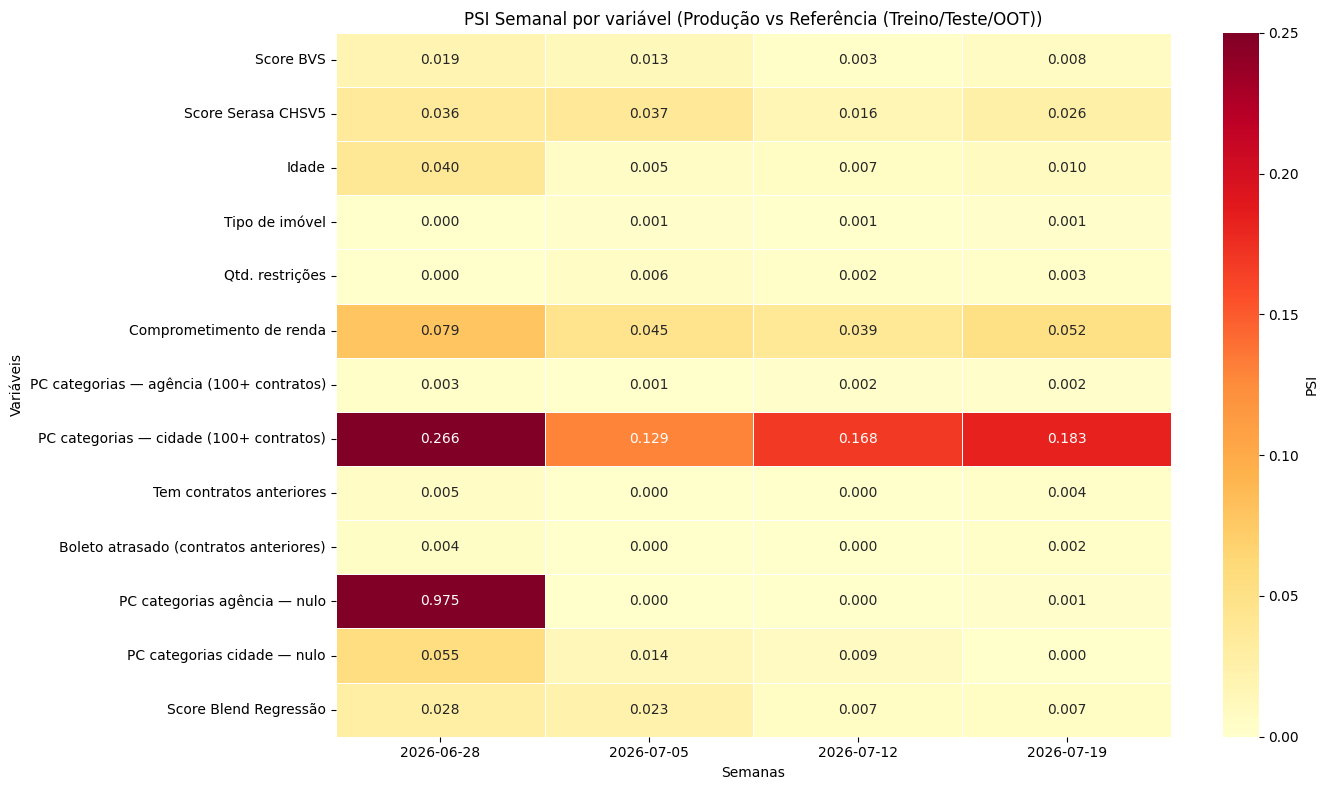

In [670]:
pivot = (
    psi_weekly
    .pivot(index="variable", columns="monitoring_week", values="psi")
    .reindex(index=model_vars, columns=week_order)
    .rename(index=VARIABLE_LABELS)
)
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    vmin=0,
    vmax=0.25,
    linewidths=0.5,
    cbar_kws={"label": "PSI"},
    ax=ax,
)
ax.set_title("PSI Semanal por variável (Produção vs Referência (Treino/Teste/OOT))")
ax.set_xlabel("Semanas")
ax.set_ylabel("Variáveis")
plt.tight_layout()
plt.show()

## PSI Semanal W-1 (Última Semana Completa)

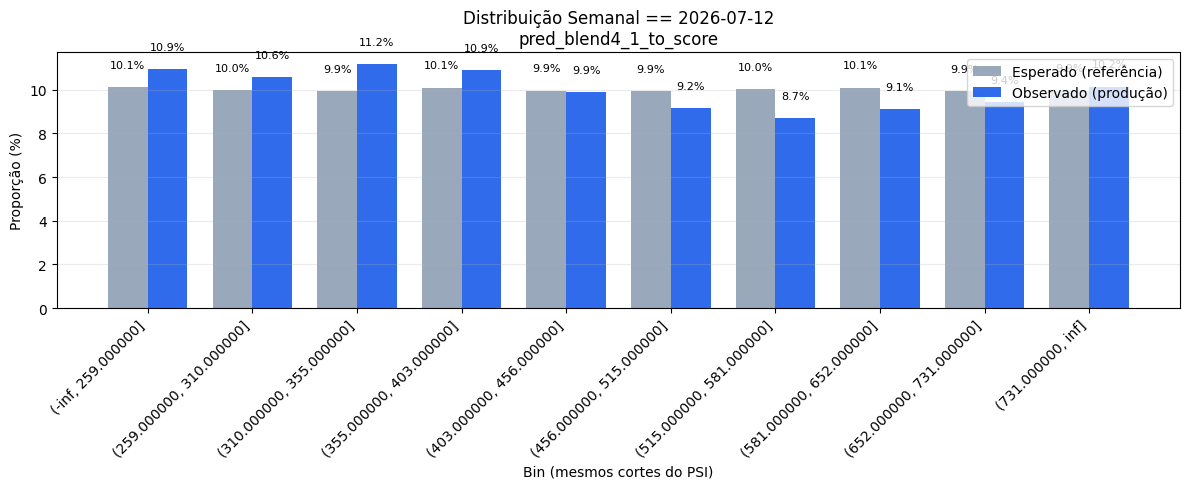

In [671]:
dist_tables = plot_top_psi_distributions(
    df_actual=df_week,
    artifact=psi_reference_artifact,
    variables=["pred_blend4_1_to_score"],
    top_n=12,
    title_prefix=f"Distribuição Semanal == {target_week}",
)

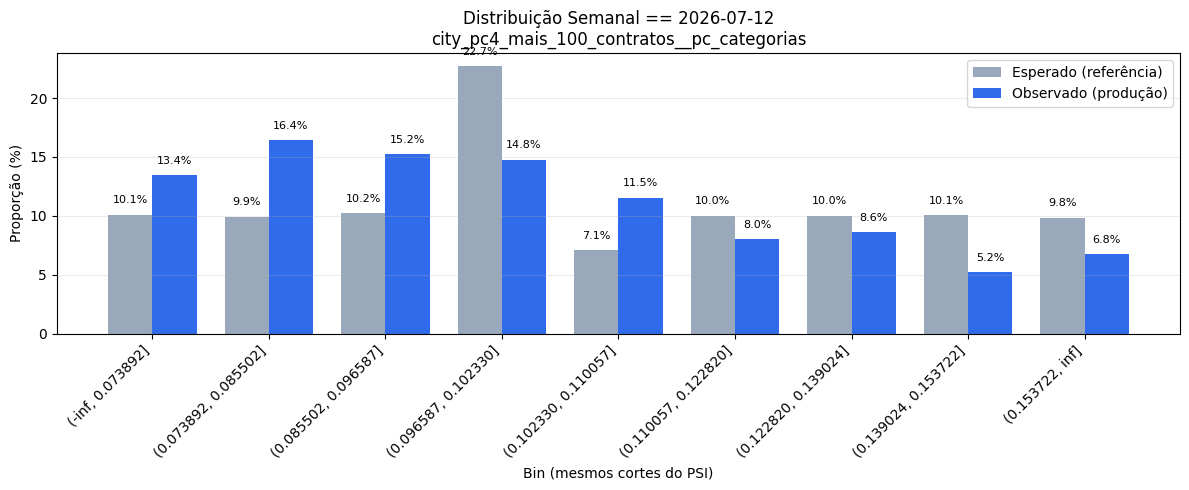

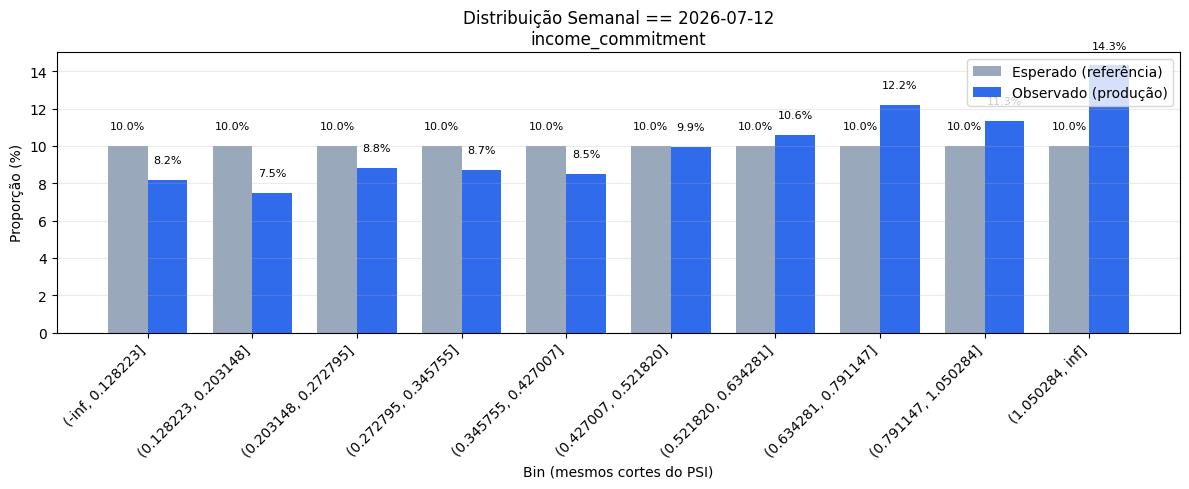

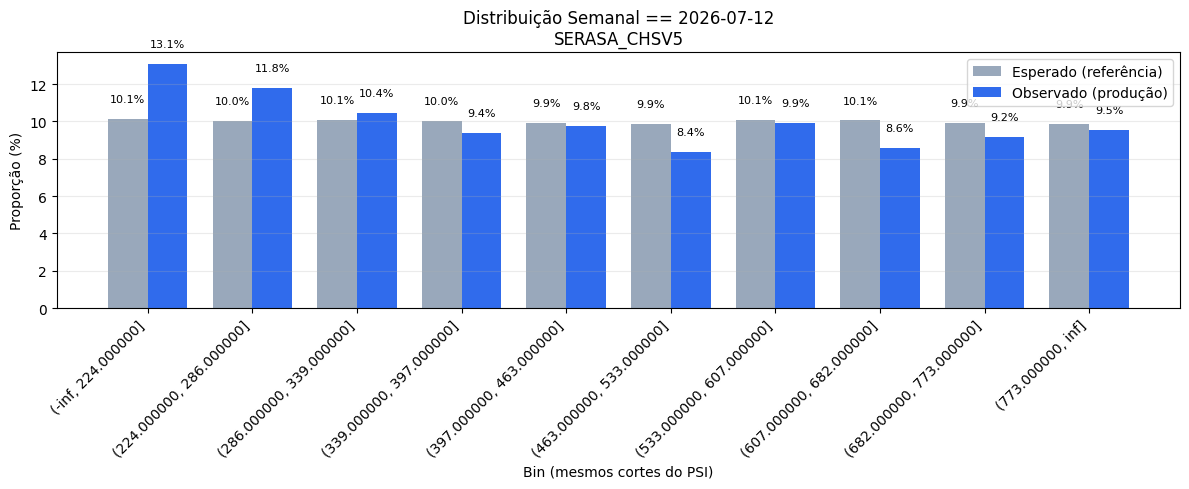

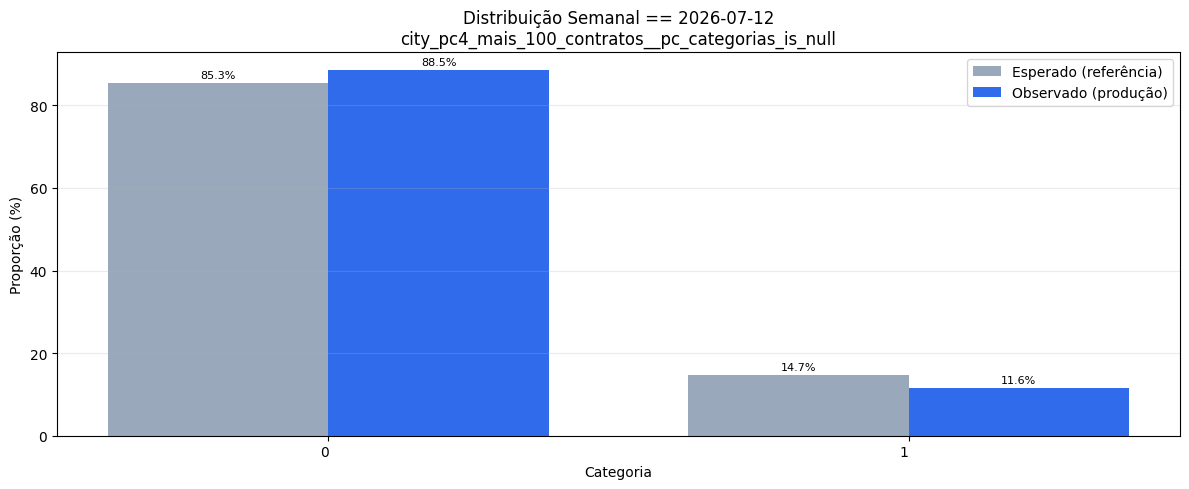

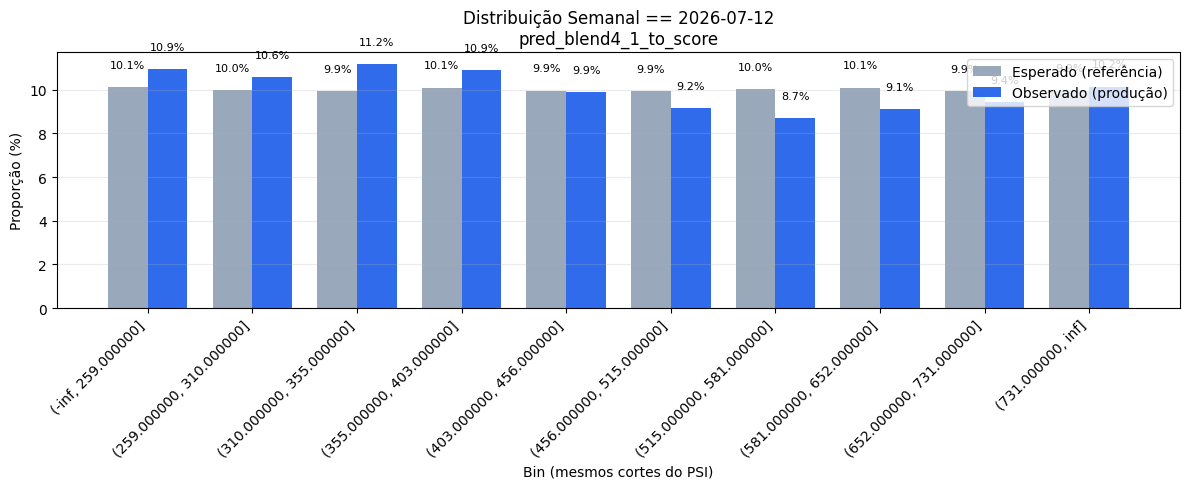

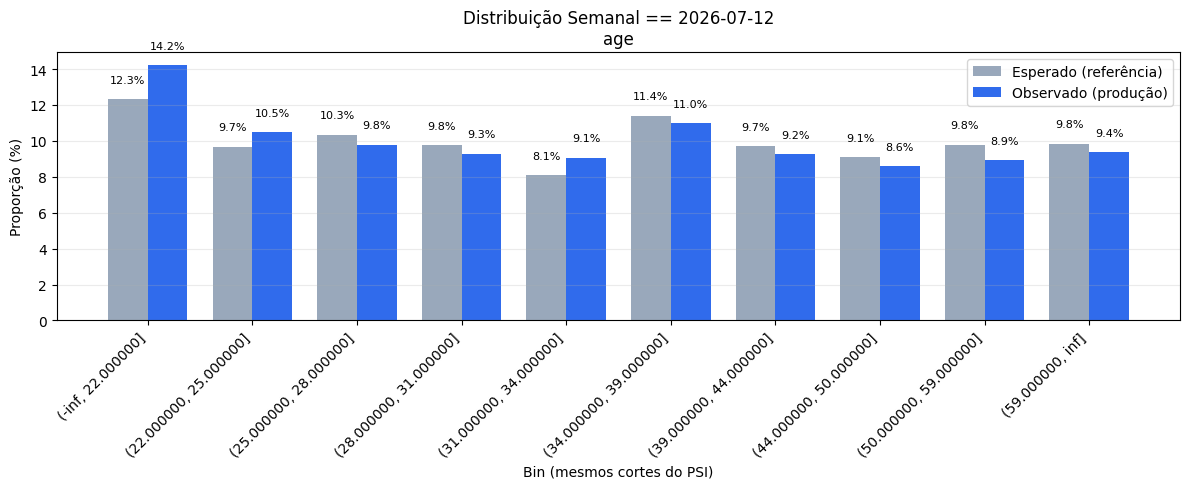

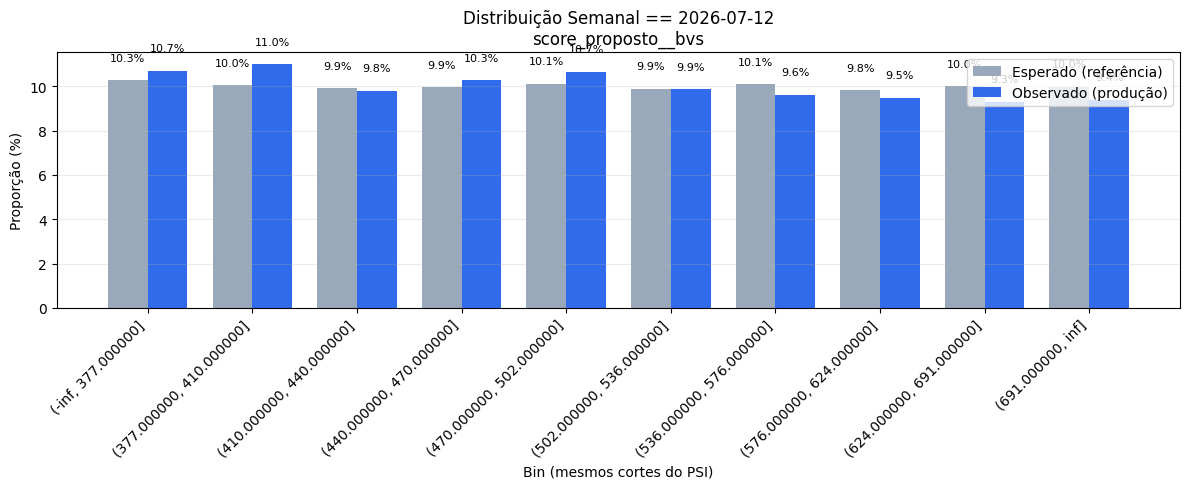

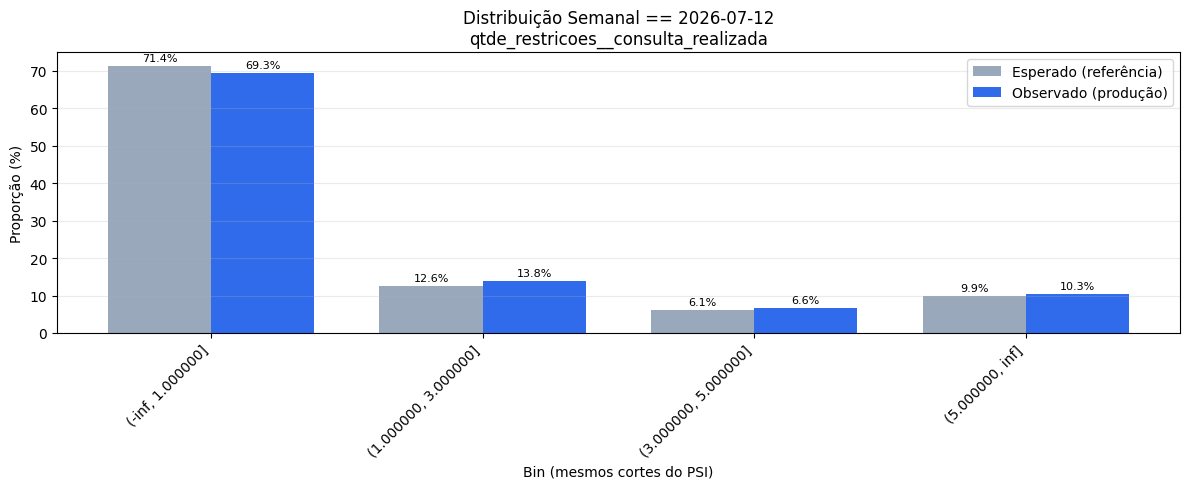

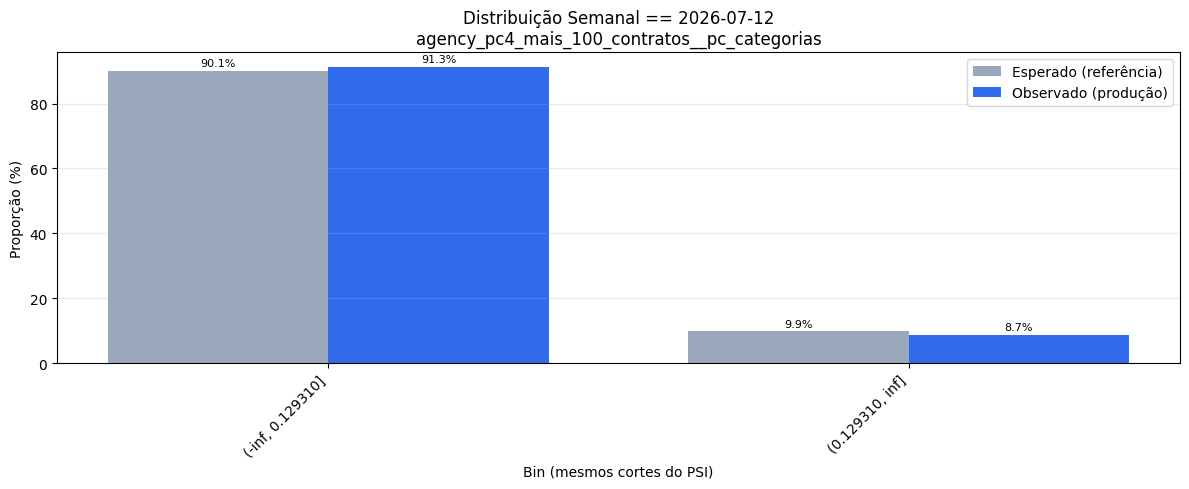

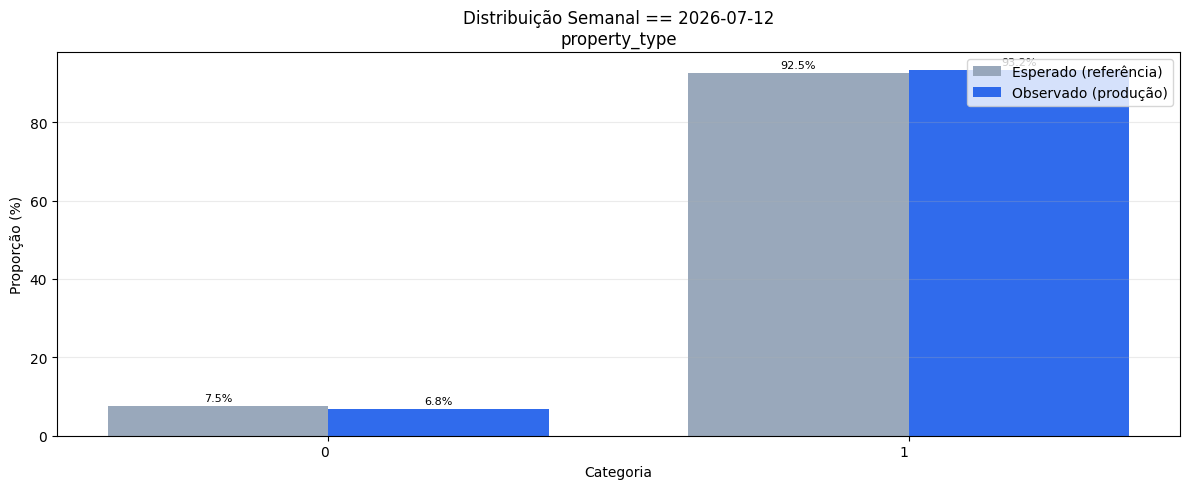

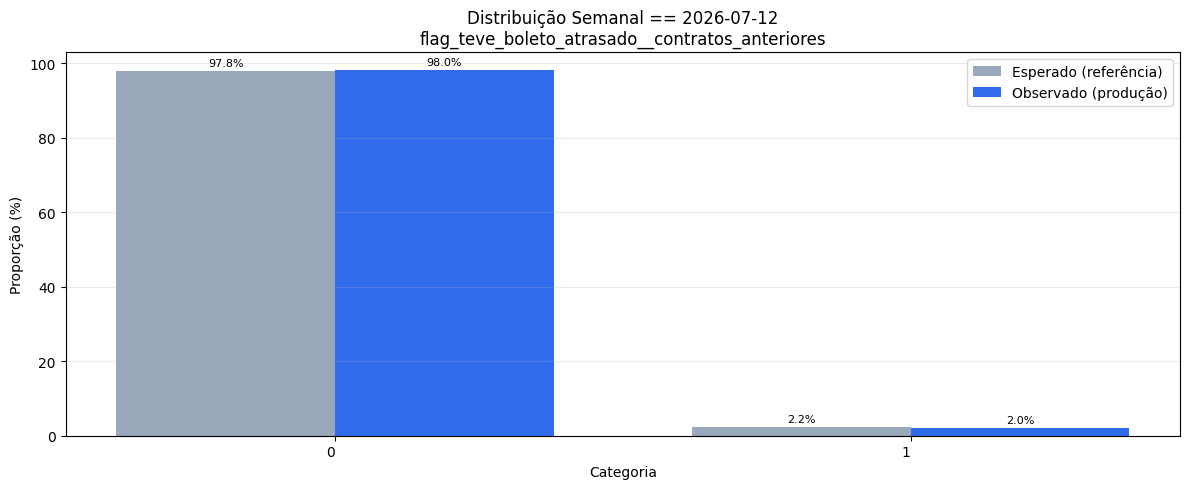

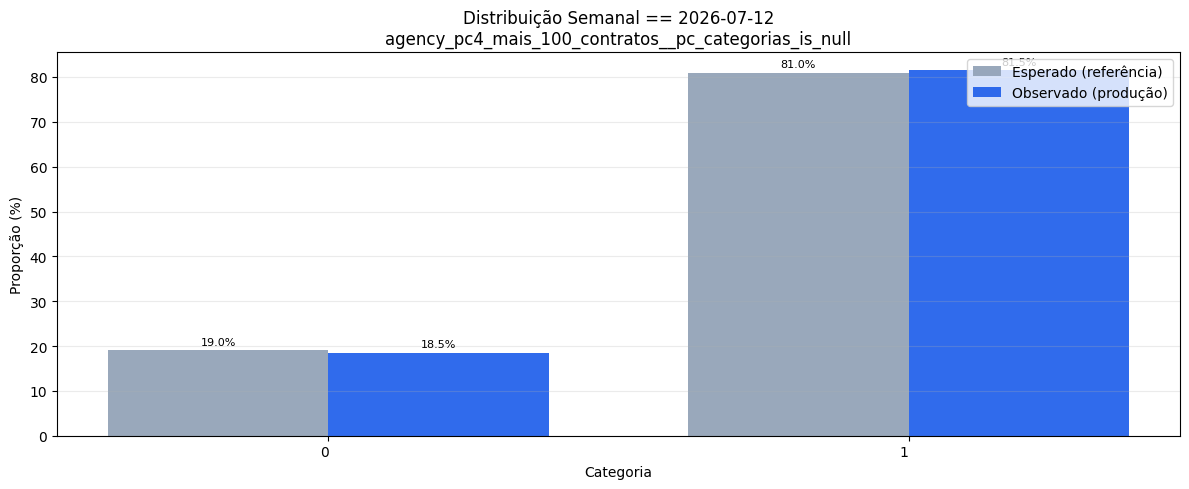

In [672]:
dist_tables = plot_top_psi_distributions(
    df_actual=df_week,
    artifact=psi_reference_artifact,
    variables=model_vars.remove("pred_blend4_1_to_score"),
    top_n=12,
    title_prefix=f"Distribuição Semanal == {target_week}",
)

# Negado Direto - BVS

Garantir que não estamos comprando SERASA para esse público

Esperado: 10-11% do público OOT reprova direto por BVS (Blend4).

In [673]:
REGRA_ORDER = ["BLEND4", "E_BVS"]
REGRA_COLOR_MAP = {
    "BLEND4": "#3B82F6",
    "E_BVS": "#F59E0B",
}

df_monitor = filter_monitoring_week_window(df_uniprop[df_uniprop["message_decisao"] == "BLEND_4"], n_weeks=6, mode="rolling")

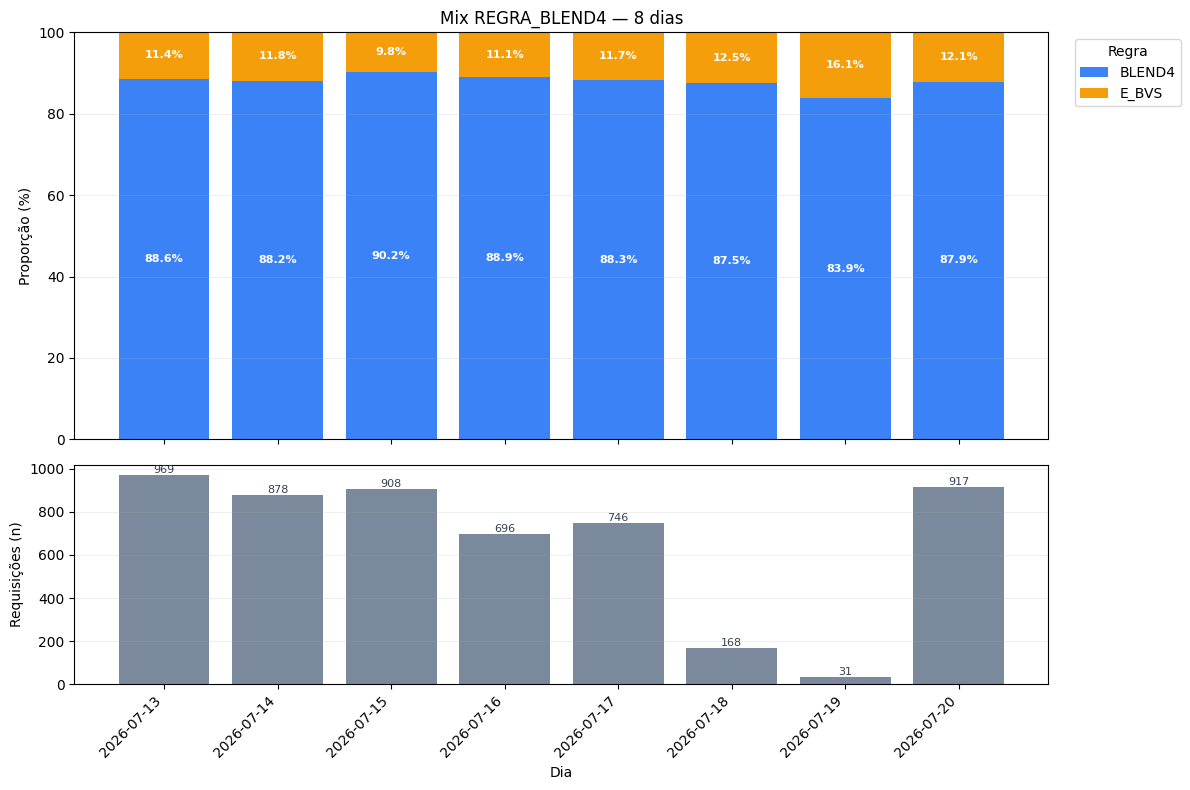

In [674]:
# Diário (mesma base, janela diária)
df_daily = filter_monitoring_window(df_monitor, n_days=8, mode="rolling")
plot_daily_mix(
    df_daily,
    category_col="REGRA_BLEND_4",
    title=f"Mix REGRA_BLEND4 — 8 dias",
    category_order=REGRA_ORDER,
    color_map=REGRA_COLOR_MAP,
    legend_title="Regra",
    min_label_pct=1.0,
)

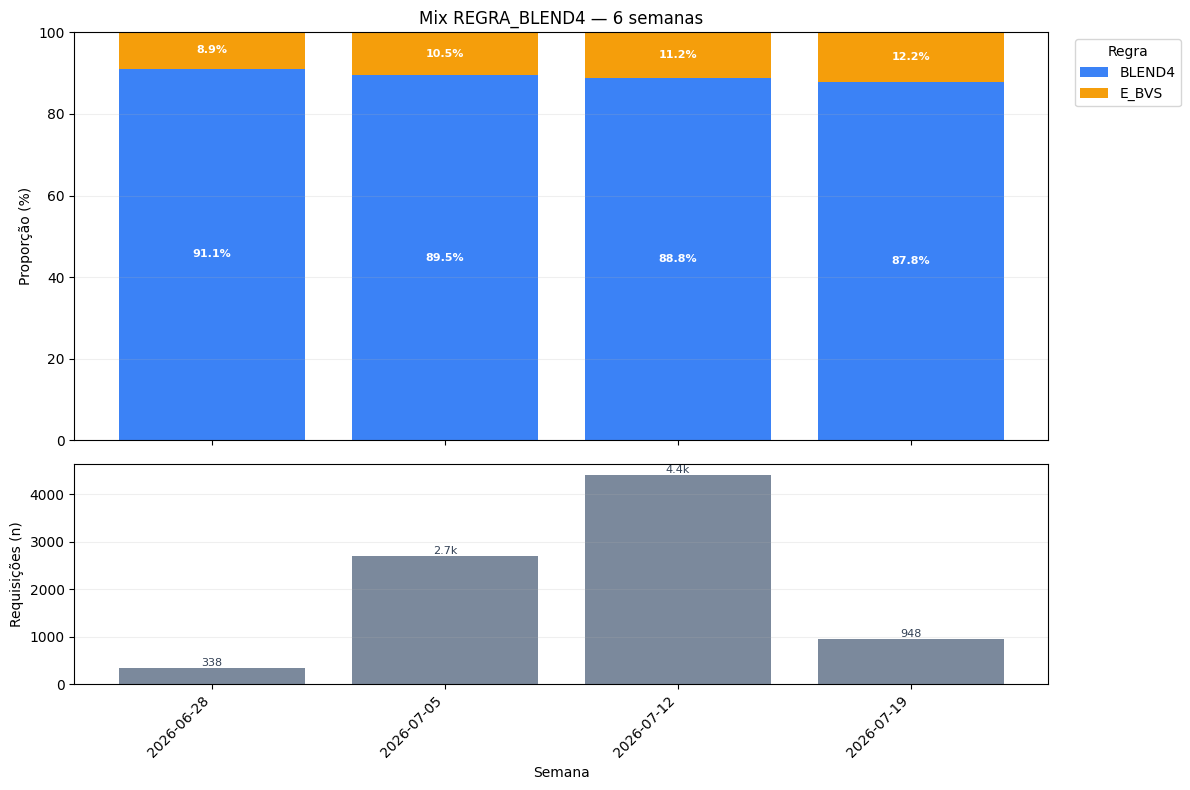

In [675]:
# Semanal
plot_weekly_mix(
    df_monitor,
    category_col="REGRA_BLEND_4",
    title="Mix REGRA_BLEND4 — 6 semanas",
    category_order=REGRA_ORDER,
    color_map=REGRA_COLOR_MAP,
    legend_title="Regra",
    min_label_pct=3.0,
)

# Falhas (BVS, Serasa)

In [676]:
df_bvs_mon = df_monitor[df_monitor["REGRA_BLEND_4"] == "E_BVS"].copy()

df_bvs_mon["status_serasa"] = np.where(
    df_bvs_mon["SCORE_SERASA"].isna(),  #Estou considerando que o score serasa é nulo quando não tem SERASA (Valores especiais?)
    "Conforme (sem SERASA)",
    "Violação (com SERASA)",
)

SERASA_STATUS_ORDER = ["Conforme (sem SERASA)", "Violação (com SERASA)"]
SERASA_STATUS_COLORS = {
    "Conforme (sem SERASA)": "#22C55E",
    "Violação (com SERASA)": "#EF4444",
}

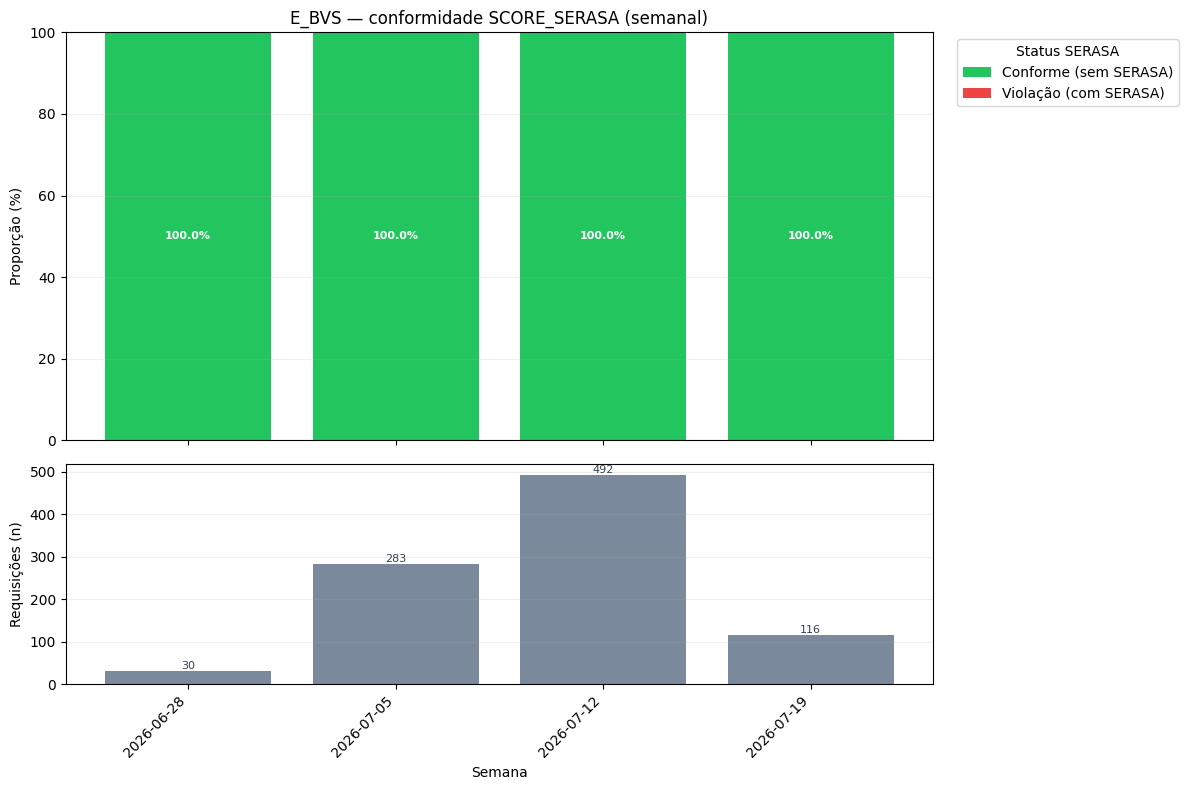

In [677]:
plot_weekly_mix(
    df_bvs_mon,
    category_col="status_serasa",
    title="E_BVS — conformidade SCORE_SERASA (semanal)",
    category_order=SERASA_STATUS_ORDER,
    color_map=SERASA_STATUS_COLORS,
    legend_title="Status SERASA",
    reverse_stack=True,  # violação no topo, mais visível
    min_label_pct=1.0,
)

In [678]:
df_E_BVS_mon = df_monitor[df_monitor["REGRA_BLEND_4"] == "E_BVS"].copy()

score_bvs = pd.to_numeric(df_E_BVS_mon["SCORE_BVS"], errors="coerce")

df_E_BVS_mon["status_bvs"] = np.select(
    [
        score_bvs.isna(),
        (score_bvs >= 0) & (score_bvs <= 334),
        (score_bvs < 0) | (score_bvs > 334),
    ],
    [
        "Violação (NaN)",
        "Conforme (0-334)",
        "Violação (fora da faixa)",
    ],
    default="Violação (NaN)",
)

BLEND4_STATUS_ORDER = [
    "Conforme (0-334)",
    "Violação (NaN)",
    "Violação (fora da faixa)",
]
BLEND4_STATUS_COLORS = {
    "Conforme (0-334)": "#22C55E",
    "Violação (NaN)": "#EF4444",
    "Violação (fora da faixa)": "#F97316",
}

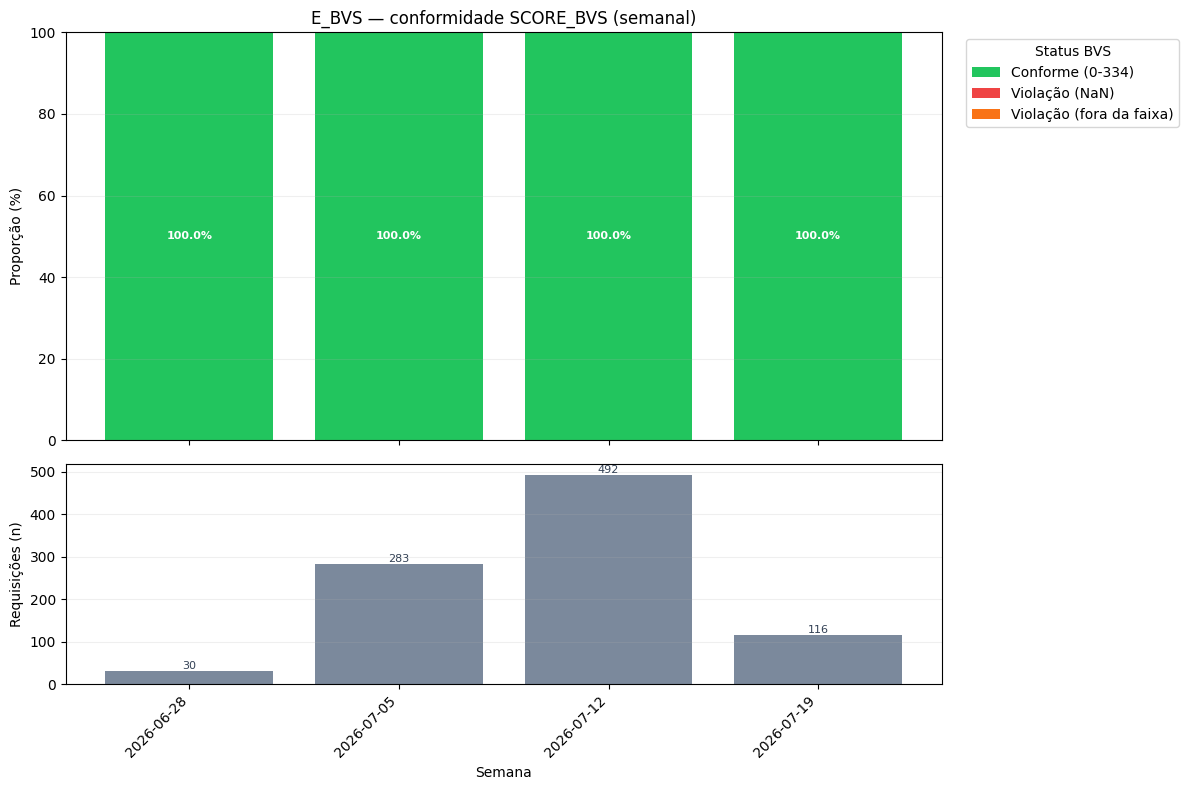

In [679]:
plot_weekly_mix(
    df_E_BVS_mon,
    category_col="status_bvs",
    title="E_BVS — conformidade SCORE_BVS (semanal)",
    category_order=BLEND4_STATUS_ORDER,
    color_map=BLEND4_STATUS_COLORS,
    legend_title="Status BVS",
    reverse_stack=True,
    min_label_pct=1.0,
)

In [680]:
df_blend4_mon = df_monitor[df_monitor["REGRA_BLEND_4"] == "BLEND4"].copy()

# Opcional: alinhar com filtros do notebook
# df_blend4_mon = df_blend4_mon[
#     (df_blend4_mon["income"] > 0) & (df_blend4_mon["qtd_proponentes"] == 1)
# ]

score_serasa = pd.to_numeric(df_blend4_mon["SCORE_SERASA"], errors="coerce")
score_bvs = pd.to_numeric(df_blend4_mon["SCORE_BVS"], errors="coerce")

df_blend4_mon["status_serasa"] = np.select(
    [
        score_serasa.isna(),
        (score_serasa >= 0) & (score_serasa <= 1000),
        (score_serasa < 0) | (score_serasa > 1000),
    ],
    [
        "Violação (NaN)",
        "Conforme (0–1000)",
        "Violação (fora da faixa)",
    ],
    default="Violação (NaN)",
)

df_blend4_mon["status_bvs"] = np.select(
    [
        score_bvs.isna(),
        (score_bvs >= 335) & (score_bvs <= 1000),
        (score_bvs < 0) | (score_bvs > 1000),
    ],
    [
        "Violação (NaN)",
        "Conforme (335–1000)",
        "Violação (fora da faixa)",
    ],
    default="Violação (NaN)",
)
SERASA_STATUS_ORDER = [
    "Conforme (0–1000)",
    "Violação (NaN)",
    "Violação (fora da faixa)",
]

SERASA_STATUS_COLORS = {
    "Conforme (0–1000)": "#22C55E",
    "Violação (NaN)": "#EF4444",
    "Violação (fora da faixa)": "#F97316",
}

BVS_STATUS_ORDER = [
    "Conforme (335–1000)",
    "Violação (NaN)",
    "Violação (fora da faixa)",
]

BVS_STATUS_COLORS = {
    "Conforme (335–1000)": "#22C55E",
    "Violação (NaN)": "#EF4444",
    "Violação (fora da faixa)": "#F97316",
}

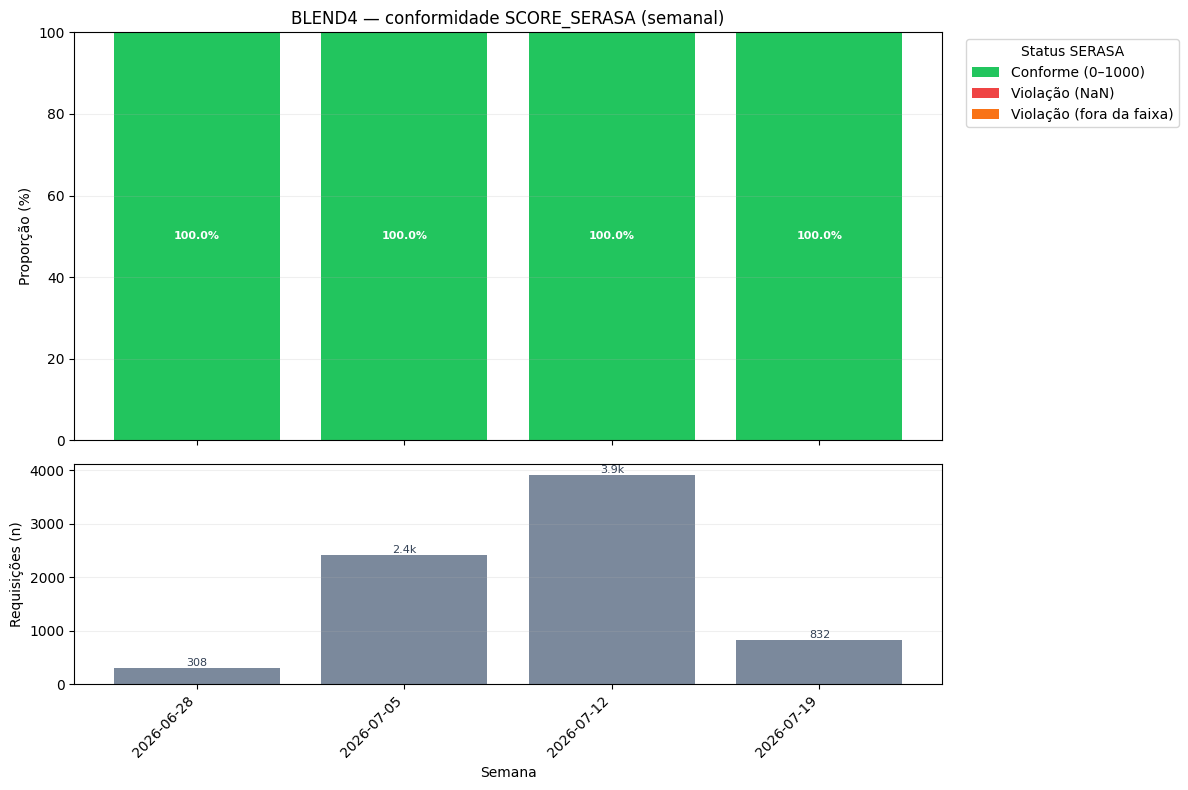

In [681]:
plot_weekly_mix(
    df_blend4_mon,
    category_col="status_serasa",
    title="BLEND4 — conformidade SCORE_SERASA (semanal)",
    category_order=SERASA_STATUS_ORDER,
    color_map=SERASA_STATUS_COLORS,
    legend_title="Status SERASA",
    reverse_stack=True,
    min_label_pct=1.0,
)

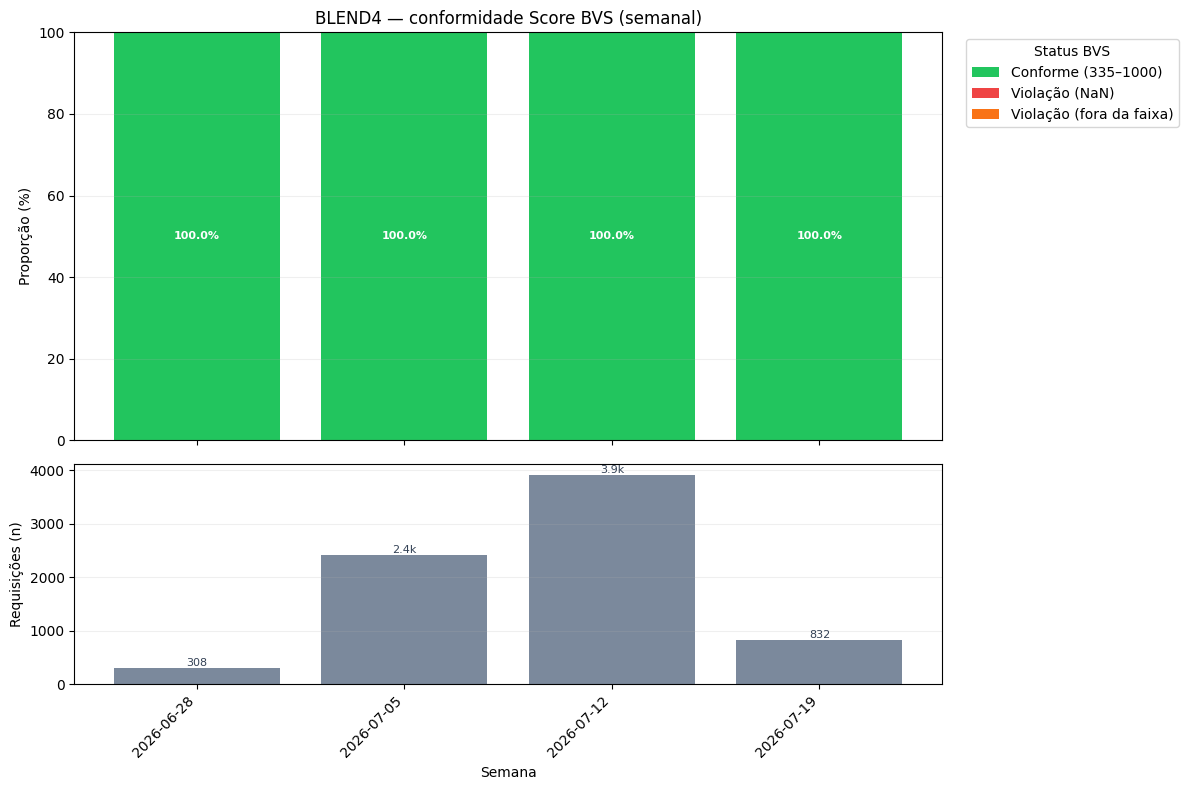

In [682]:
plot_weekly_mix(
    df_blend4_mon,
    category_col="status_bvs",
    title="BLEND4 — conformidade Score BVS (semanal)",
    category_order=BVS_STATUS_ORDER,
    color_map=BVS_STATUS_COLORS,
    legend_title="Status BVS",
    reverse_stack=True,
    min_label_pct=1.0,
)

In [683]:
df_blend4_mon = df_monitor[df_monitor["REGRA_BLEND_4"] == "BLEND4"].copy()

renda = pd.to_numeric(df_blend4_mon["RENDA"], errors="coerce")

df_blend4_mon["status_renda"] = np.select(
    [
        renda.isna(),
        renda == 0,
        renda > 0,
    ],
    [
        "Violação (NaN)",
        "Violação (0)",
        "Conforme (> 0)",
    ],
    default="Violação (NaN)",
)

RENDA_STATUS_ORDER = [
    "Conforme (> 0)",
    "Violação (NaN)",
    "Violação (0)",
]

RENDA_STATUS_COLORS = {
    "Conforme (> 0)": "#22C55E",
    "Violação (NaN)": "#EF4444",
    "Violação (0)": "#F97316",
}

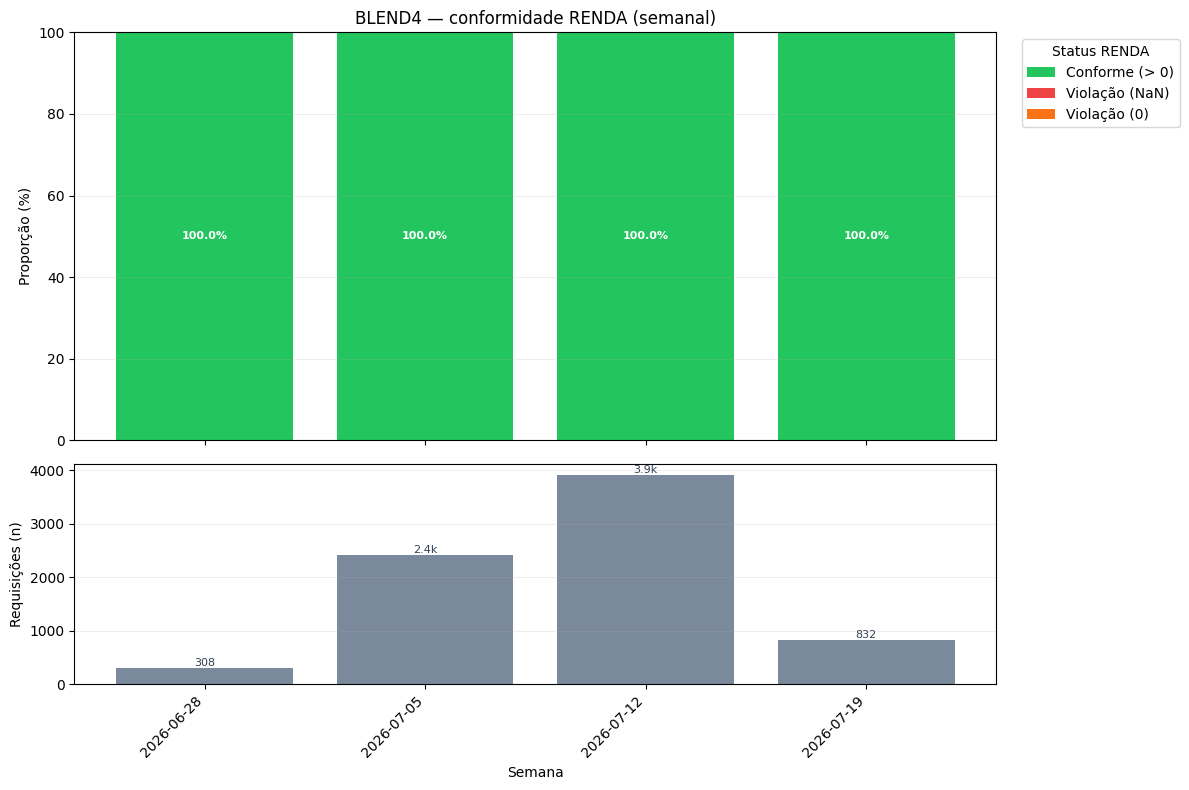

In [684]:
plot_weekly_mix(
    df_blend4_mon,
    category_col="status_renda",
    title="BLEND4 — conformidade RENDA (semanal)",
    category_order=RENDA_STATUS_ORDER,
    color_map=RENDA_STATUS_COLORS,
    legend_title="Status RENDA",
    reverse_stack=True,
    min_label_pct=1.0,
)

# PSI Base Geral Uniproponente

## Dia e Semana Raw

In [685]:
WINDOW_DAYS = 8

df_daily = filter_monitoring_window(
    df_uniprop,
    n_days=WINDOW_DAYS,
    mode="rolling",
)
print(f"Período: {df_daily['requested_at'].min()} → {df_daily['requested_at'].max()}")
print(f"Volume total: {len(df_daily):,}")

Período: 2026-07-13 00:00:00 → 2026-07-20 00:00:00
Volume total: 34,306


In [686]:
WINDOW_WEEKS = 6

df_weekly = filter_monitoring_week_window(
    df_uniprop,
    n_weeks=WINDOW_WEEKS,
    mode="rolling",
)
print(f"Semanas: {df_weekly['year_week'].nunique()} | Volume: {len(df_weekly):,}")
print(f"Período: {df_weekly['requested_at'].min()} → {df_weekly['requested_at'].max()}")

Semanas: 4 | Volume: 66,449
Período: 2026-07-03 00:00:00 → 2026-07-20 00:00:00


In [687]:
PSI_REFERENCE_PATH = ANALYTICS_DIR / "blend4_bvs_score_psi_reference.pkl"
psi_reference_artifact_bvs = load_psi_reference(PSI_REFERENCE_PATH)

In [688]:
PSI_REFERENCE_PATH = ANALYTICS_DIR / "psi_income_rental_reference.pkl"
psi_reference_artifact_raw = load_psi_reference(PSI_REFERENCE_PATH)

In [689]:
daily_blend4 = df_daily[df_daily["message_decisao"] == "BLEND_4"].copy()
weekly_blend4 = df_weekly[df_weekly["message_decisao"] == "BLEND_4"].copy()

psi_daily_bvs = monitor_daily_psi(
    df_production=daily_blend4,
    artifact=psi_reference_artifact_bvs,
    date_col="requested_at",
    baseline_ref=psi_baseline_ref,
    variables=["SCORE_BVS"],
)

psi_weekly_bvs = monitor_weekly_psi(
    df_production=weekly_blend4,
    artifact=psi_reference_artifact_bvs,
    baseline_ref=psi_baseline_ref,
    variables=["SCORE_BVS"],
)

psi_daily_income_rental = monitor_daily_psi(
    df_production=daily_blend4,
    artifact=psi_reference_artifact_raw,
    date_col="requested_at",
    baseline_ref=psi_baseline_ref,
    variables=["income", "rental_value"],
)

psi_weekly_income_rental = monitor_weekly_psi(
    df_production=weekly_blend4,
    artifact=psi_reference_artifact_raw,
    baseline_ref=psi_baseline_ref,
    variables=["income", "rental_value"],
)

In [690]:
target_day = pd.to_datetime(daily_blend4["requested_at"]).max().strftime("%Y-%m-%d")
print(f"Target day: {target_day}")
df_day = daily_blend4[
    pd.to_datetime(daily_blend4["requested_at"]).dt.strftime("%Y-%m-%d") == target_day
]

Target day: 2026-07-20


In [691]:
target_week = week_order[-2]
print(f"Target Week == {target_week} (Última Semana Completa)")
df_week = weekly_blend4[
    weekly_blend4["year_week"] == target_week]

Target Week == 2026-07-12 (Última Semana Completa)


In [692]:
# psi_daily
# POR QUE TEM NAN

## PSI RAW BVS

In [693]:
# pivot = (
#     psi_daily_bvs
#     .pivot(index="variable", columns="monitoring_day", values="psi")
#     .reindex(["SCORE_BVS"])
#     .rename(index={"SCORE_BVS": "Score BVS"})
# )
# fig, ax = plt.subplots(figsize=(10, 2))
# sns.heatmap(
#     pivot,
#     annot=True,
#     fmt=".3f",
#     cmap="YlOrRd",
#     vmin=0,
#     vmax=0.25,
#     linewidths=0.5,
#     cbar_kws={"label": "PSI"},
#     ax=ax,
# )
# ax.set_title("PSI diário por variável (Produção vs Referência (Treino/Teste/OOT))")
# ax.set_xlabel("Dia")
# ax.set_ylabel("Variáveis")
# plt.tight_layout()
# plt.show()

In [694]:
# dist_tables = plot_top_psi_distributions(
#     df_actual=df_day,
#     artifact=psi_reference_artifact_bvs,
#     variables=["SCORE_BVS"],
#     title_prefix=f"Distribuição diária — {target_day}",
# )

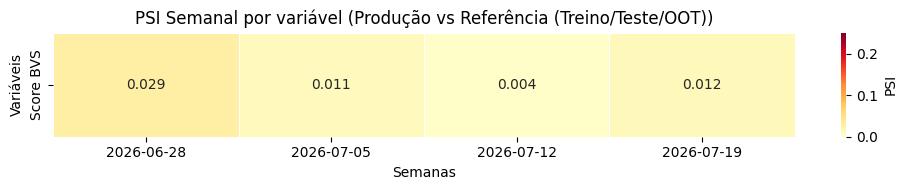

In [695]:
pivot = (
    psi_weekly_bvs
    .pivot(index="variable", columns="monitoring_week", values="psi")
    .reindex(["SCORE_BVS"])
    .rename(index={"SCORE_BVS": "Score BVS"})
)
fig, ax = plt.subplots(figsize=(10, 2))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    vmin=0,
    vmax=0.25,
    linewidths=0.5,
    cbar_kws={"label": "PSI"},
    ax=ax,
)
ax.set_title("PSI Semanal por variável (Produção vs Referência (Treino/Teste/OOT))")
ax.set_xlabel("Semanas")
ax.set_ylabel("Variáveis")
plt.tight_layout()
plt.show()

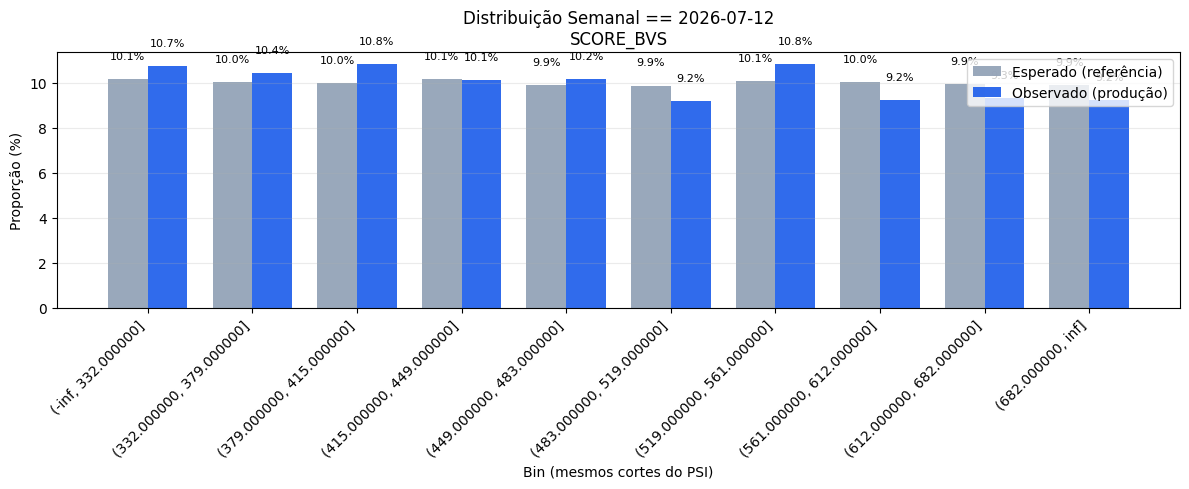

In [696]:
dist_tables = plot_top_psi_distributions(
    df_actual=df_week,
    artifact=psi_reference_artifact_bvs,
    variables=["SCORE_BVS"],
    title_prefix=f"Distribuição Semanal == {target_week}",
)

In [697]:
# o que é cada BIN: CORTES

## PSI RAW Renda e Aluguel

In [698]:
# pivot = (
#     psi_daily_income_rental
#     .pivot(index="variable", columns="monitoring_day", values="psi")
#     .reindex(["income", "rental_value"])
#     .rename(index={"income": "Renda", "rental_value": "Aluguel"})
# )
# fig, ax = plt.subplots(figsize=(10, 4))
# sns.heatmap(
#     pivot,
#     annot=True,
#     fmt=".3f",
#     cmap="YlOrRd",
#     vmin=0,
#     vmax=0.25,
#     linewidths=0.5,
#     cbar_kws={"label": "PSI"},
#     ax=ax,
# )
# ax.set_title("PSI diário por variável (Produção vs Referência (Treino/Teste/OOT))")
# ax.set_xlabel("Dia")
# ax.set_ylabel("Variáveis")
# plt.tight_layout()
# plt.show()

In [699]:
# dist_tables = plot_top_psi_distributions(
#     df_actual=df_day,
#     artifact=psi_reference_artifact_raw,
#     variables=["income", "rental_value"],
#     title_prefix=f"Distribuição diária — {target_day}",
# )

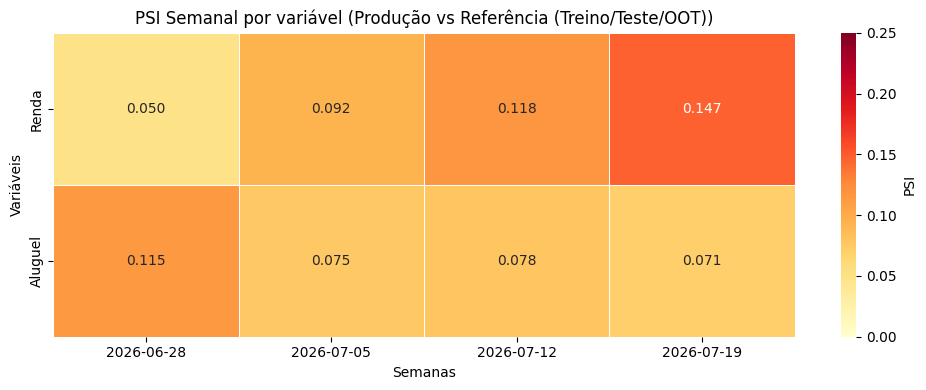

In [700]:
pivot = (
    psi_weekly_income_rental
    .pivot(index="variable", columns="monitoring_week", values="psi")
    .reindex(["income", "rental_value"])
    .rename(index={"income": "Renda", "rental_value": "Aluguel"})
)
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    vmin=0,
    vmax=0.25,
    linewidths=0.5,
    cbar_kws={"label": "PSI"},
    ax=ax,
)
ax.set_title("PSI Semanal por variável (Produção vs Referência (Treino/Teste/OOT))")
ax.set_xlabel("Semanas")
ax.set_ylabel("Variáveis")
plt.tight_layout()
plt.show()

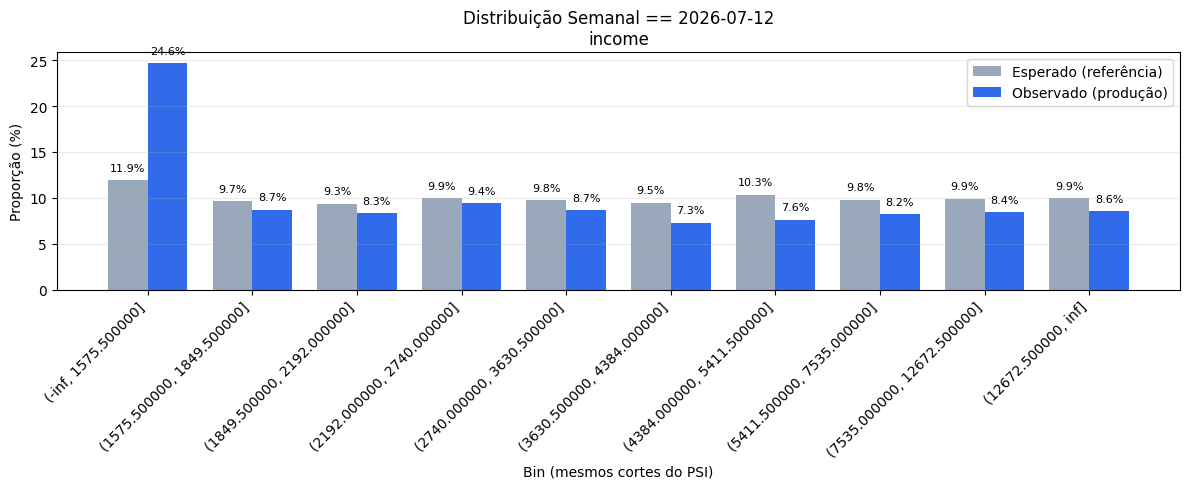

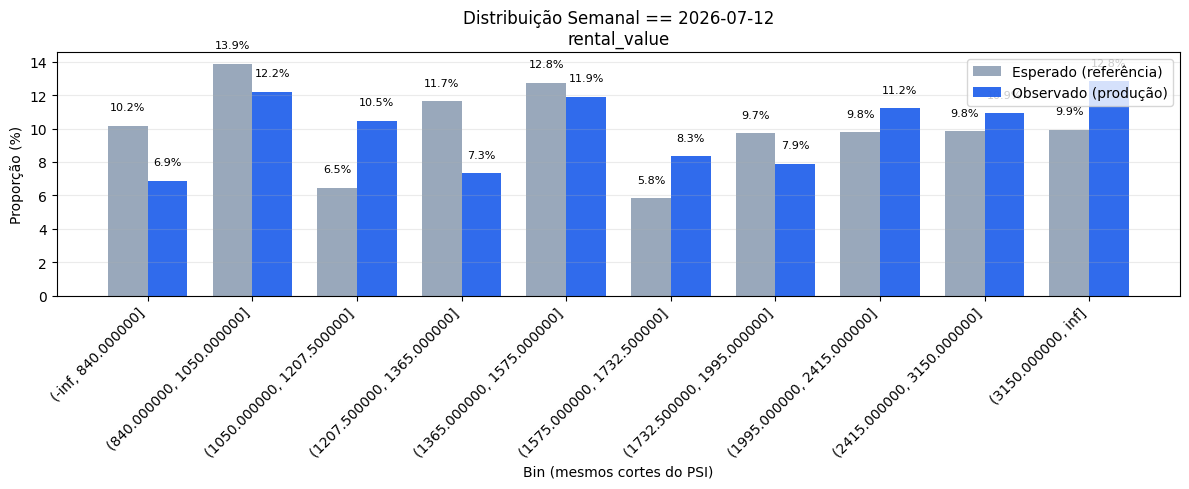

In [701]:
dist_tables = plot_top_psi_distributions(
    df_actual=df_week,
    artifact=psi_reference_artifact_raw,
    variables=["income", "rental_value"],
    title_prefix=f"Distribuição Semanal == {target_week}",
)

# Outras Análises

Análises Extras que servem para avaliar possíveis alterações que vemos na nossa base de leads.

## Multiproponente vs Uniproponente na CR

In [702]:
PROPONENTE_ORDER = ["Uniproponente", "Multiproponente"]

PROPONENTE_COLOR_MAP = {
    "Uniproponente": "#94A3B8",   # slate
    "Multiproponente": "#3B82F6", # blue
}

PROPONENTE_TEXT_COLOR_MAP = {
    "Uniproponente": "white",
    "Multiproponente": "white",
}

def add_tipo_proponente(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["tipo_proponente"] = np.where(
        out["qtd_proponentes"] == 1,
        "Uniproponente",
        "Multiproponente",
    )
    return out

# Use df (BLEND4 + income > 0) ou df_raw (base completa)
df_prop = add_tipo_proponente(df_raw)

print(df_prop["tipo_proponente"].value_counts(normalize=True).mul(100).round(2))
print(df_prop["tipo_proponente"].value_counts())

tipo_proponente
Uniproponente      96.47
Multiproponente     3.53
Name: proportion, dtype: float64
tipo_proponente
Uniproponente      66449
Multiproponente     2432
Name: count, dtype: int64


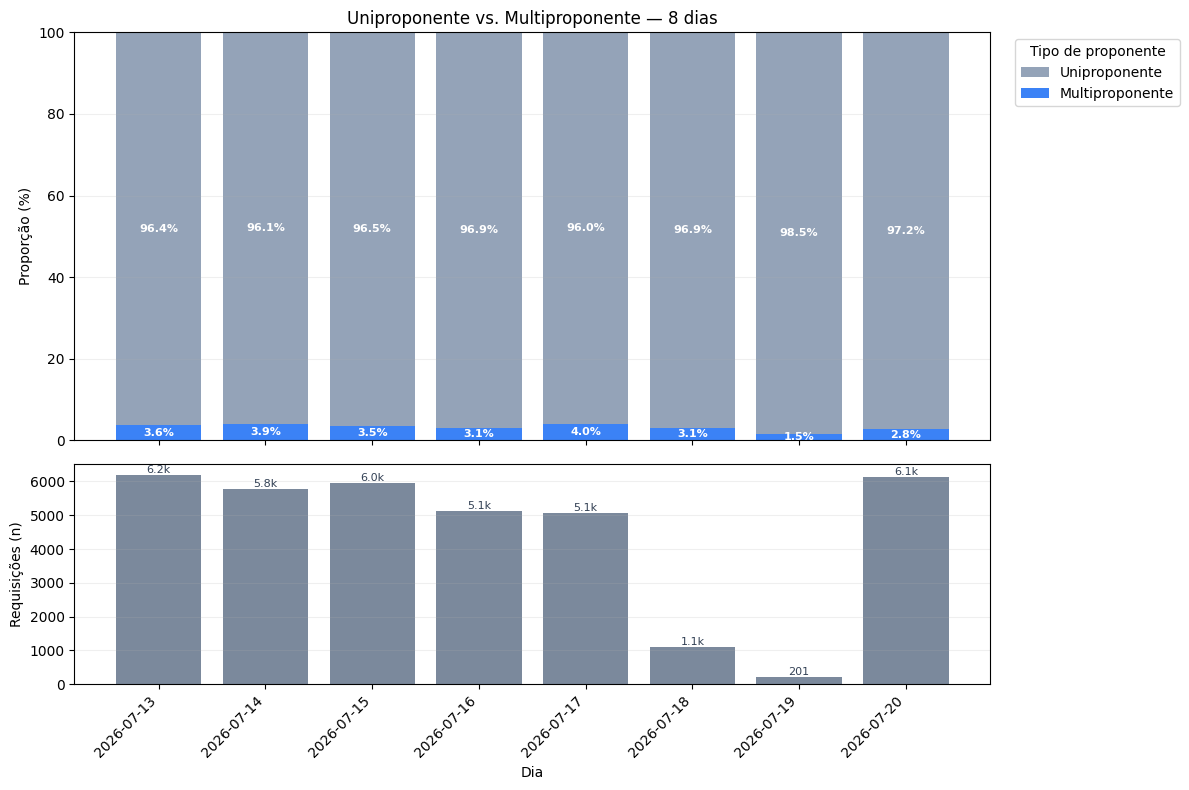

In [703]:
WINDOW_DAYS = 8

df_daily_prop = filter_monitoring_window(
    df_prop,
    n_days=WINDOW_DAYS,
    mode="rolling",
)

plot_daily_mix(
    df_daily_prop,
    category_col="tipo_proponente",
    title=f"Uniproponente vs. Multiproponente — {WINDOW_DAYS} dias",
    category_order=PROPONENTE_ORDER,
    color_map=PROPONENTE_COLOR_MAP,
    text_color_map=PROPONENTE_TEXT_COLOR_MAP,
    reverse_stack=True,
    legend_title="Tipo de proponente",
    min_label_pct=1.0,
)

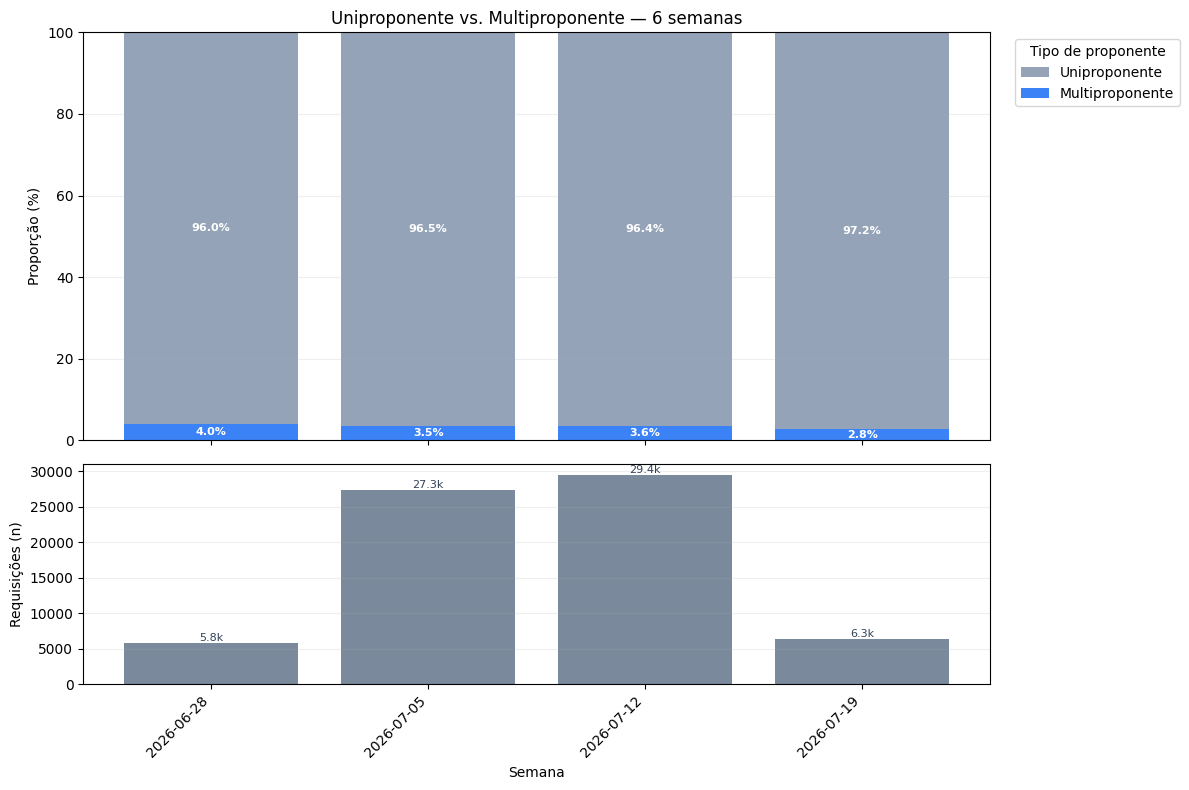

In [704]:
WINDOW_WEEKS = 6

df_weekly_prop = filter_monitoring_week_window(
    df_prop,
    n_weeks=WINDOW_WEEKS,
    mode="rolling",
)

plot_weekly_mix(
    df_weekly_prop,
    category_col="tipo_proponente",
    title=f"Uniproponente vs. Multiproponente — {WINDOW_WEEKS} semanas",
    category_order=PROPONENTE_ORDER,
    color_map=PROPONENTE_COLOR_MAP,
    text_color_map=PROPONENTE_TEXT_COLOR_MAP,
    reverse_stack=True,
    legend_title="Tipo de proponente",
    min_label_pct=1.0,
)

## Verificação de Cortes de Rating
Nesse caso, o que queremos é analisar se definição do Rating está sendo feita corretamente.

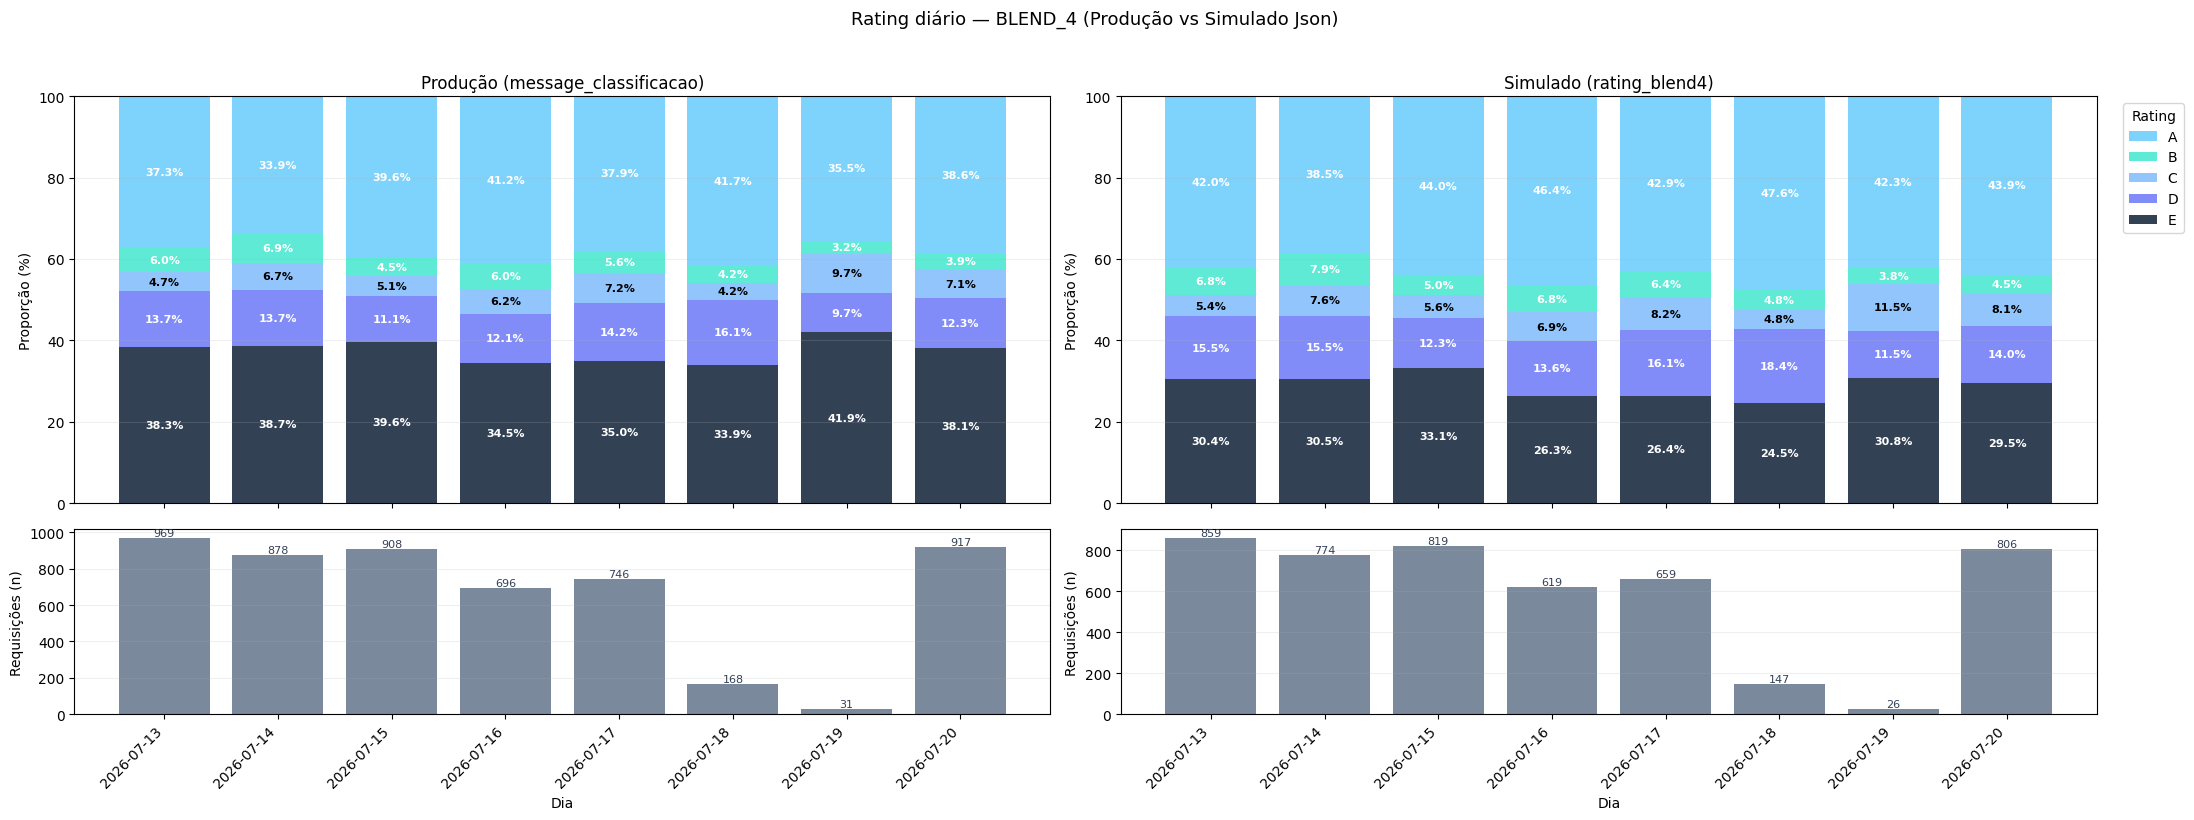

In [705]:
MODELS = ["BLEND_4"]

for model in MODELS:
    df_model = df_daily[df_daily["message_decisao"] == model]

    plot_daily_rating_comparison(
        df_model,
        title=f"Rating diário — {model} (Produção vs Simulado Json)",
        production_rating_col = "message_classificacao",
        simulated_rating_col = "rating_json_blend4",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        min_label_pct=3.0,
    )

In [706]:
for model in MODELS:
    pivot = pd.crosstab(
        df_daily.loc[df_daily["message_decisao"] == model, "message_classificacao"],
        df_daily.loc[df_daily["message_decisao"] == model, "rating_json_blend4"],
        margins=True,
    )
    print(model)
    display(pivot)

BLEND_4


rating_json_blend4,A,B,C,D,E,All
message_classificacao,,,,,,
A,2024,0,0,0,0,2024
B,0,288,0,0,0,288
C,0,0,323,0,0,323
D,0,0,0,687,0,687
E,0,0,0,0,1387,1387
All,2024,288,323,687,1387,4709


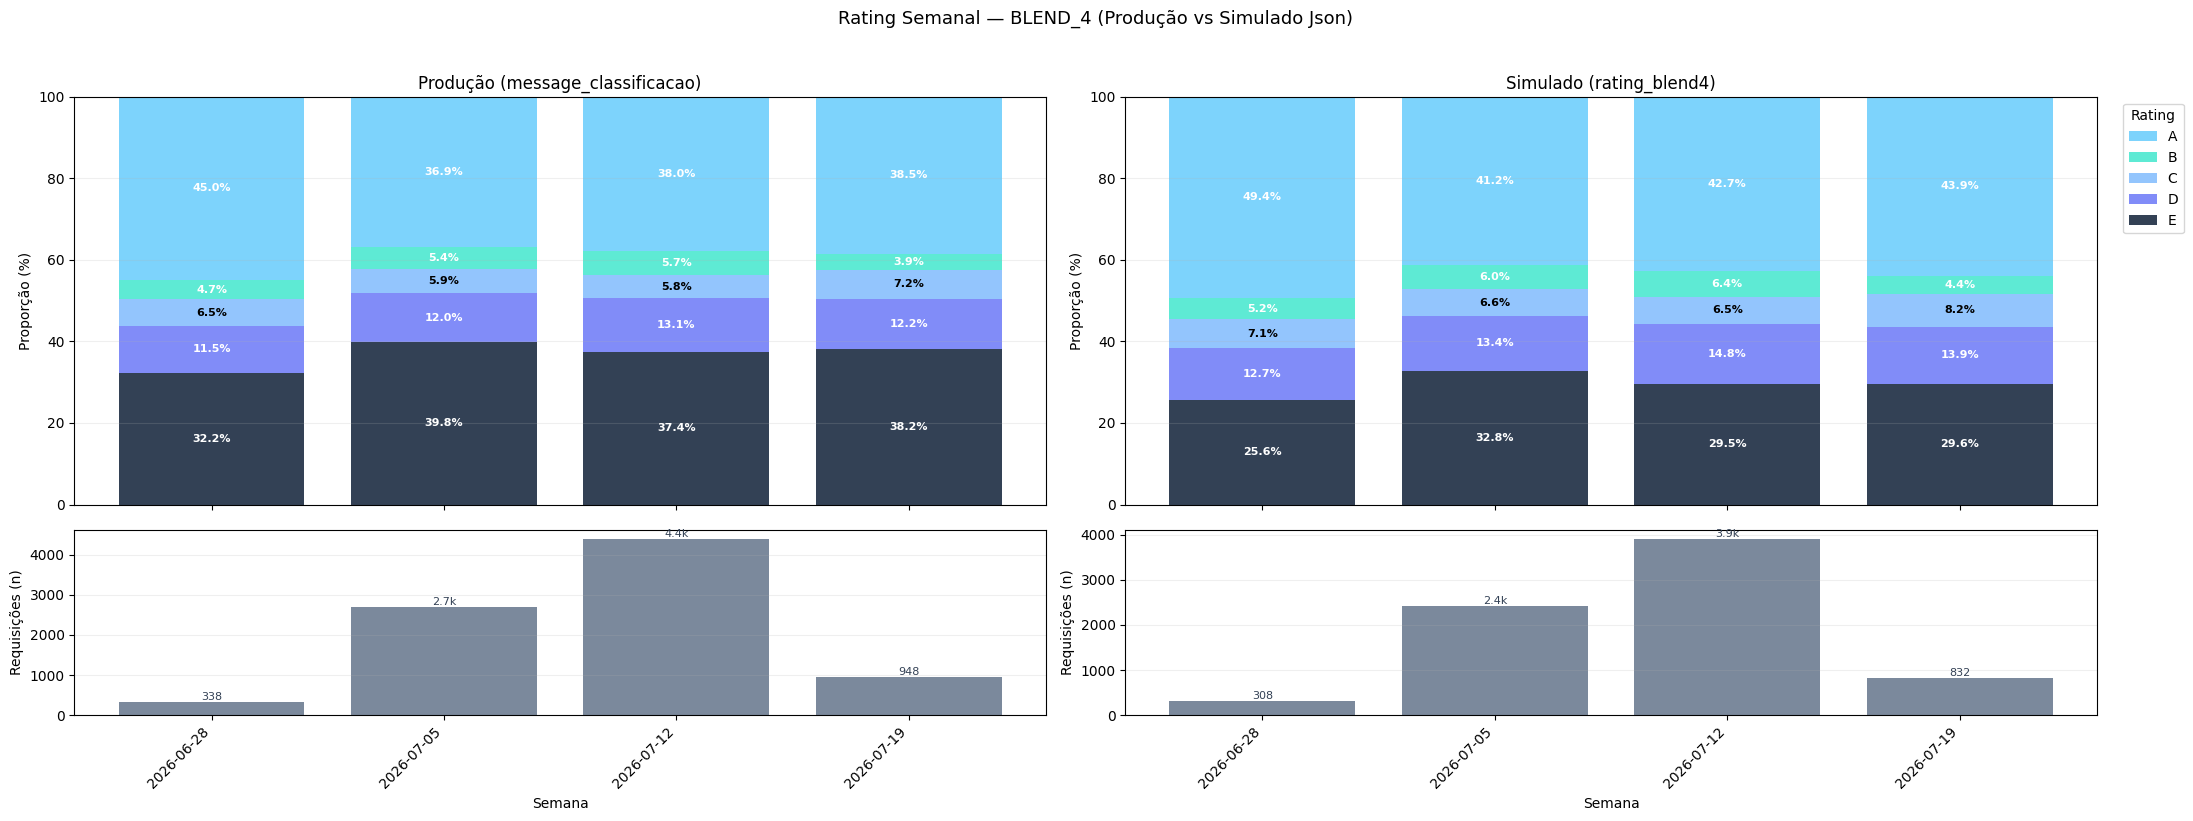

In [707]:
MODELS = ["BLEND_4"]

for model in MODELS:
    df_model = df_weekly[df_weekly["message_decisao"] == model]

    plot_weekly_rating_comparison(
        df_model,
        title=f"Rating Semanal — {model} (Produção vs Simulado Json)",
        production_rating_col = "message_classificacao",
        simulated_rating_col = "rating_json_blend4",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        min_label_pct=3.0,
    )

In [708]:
for model in MODELS:
    pivot = pd.crosstab(
        df_weekly.loc[df_weekly["message_decisao"] == model, "message_classificacao"],
        df_weekly.loc[df_weekly["message_decisao"] == model, "rating_json_blend4"],
        margins=True,
    )
    print(model)
    display(pivot)

BLEND_4


rating_json_blend4,A,B,C,D,E,All
message_classificacao,,,,,,
A,3189,0,0,0,0,3189
B,0,449,0,0,0,449
C,0,0,506,0,0,506
D,0,0,0,1059,0,1059
E,0,0,0,0,2275,2275
All,3189,449,506,1059,2275,7478


# Salvar HTML

In [709]:
import importlib
from pathlib import Path

import build_report_html

importlib.reload(build_report_html)

REPORTS_DIR = Path("Monitores")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Save the notebook (Cmd+S) before running so the HTML includes the latest outputs.
report_path = build_report_html.export_notebook_report(
    title="Monitoramento Blend4",
    output_path=REPORTS_DIR / "02.Monitoramento_Blend4_report.html",
)
print(f"Report generated: {report_path}")


Report updated: /Users/lucas.nascimento/Monitoramento_Modelos/Monitores/02.Monitoramento_Blend4_report.html (2.89 MB) | generated at 2026-07-21 15:15:00 -03
If the browser still shows old content, hard-refresh (Cmd+Shift+R).
Report generated: /Users/lucas.nascimento/Monitoramento_Modelos/Monitores/02.Monitoramento_Blend4_report.html
